# Step 2 — Confidence Analysis and RAG Handoff Threshold

This notebook analyses the **softmax confidence** of the three fine-tuned baseline models (BERT, HateBERT, RoBERTa) from `baseline_step1.ipynb`. It answers four questions:

1. **Is confidence calibrated?** — Does a model that says 80% confidence actually get 80% of those examples right?
2. **Where does confidence fail?** — Are dangerous false negatives (missed hate speech) made with high or low confidence?
3. **What is the accuracy/coverage tradeoff?** — How does macro F1 on retained examples change as we raise the confidence threshold?
4. **What goes to RAG?** — At each threshold, how many examples would be routed to the RAG system, and what is their class composition?

**Prerequisites**: `baseline_step1.ipynb` must have been run. Weights must exist in `./weights/`.

In [88]:
# Uncomment if running in Colab
# !pip install -q transformers datasets accelerate scikit-learn seaborn scipy

In [89]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.special import softmax
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
)
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import torch
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 11, 'axes.labelsize': 10})
print('Imports OK')

Imports OK


In [127]:
WEIGHTS_ROOT = './weights'

MODELS = {
    'bert-base-uncased': 'bert-base-uncased',
    'hateBERT':          'GroNLP/hateBERT',
    'roberta-base':      'roberta-base',
}

DATASETS_CFG = {
    'IHC':    {'text_col': 'post'},
    'ISHate':     {'text_col': 'text'},
    'Vicomtech':  {'text_col': 'text'},
}

MAX_LENGTH = 128
SEED       = 42

THRESHOLDS       = [0.60, 0.70, 0.80, 0.90, 0.95]  # discrete values for tables/heatmap
THRESHOLDS_SWEEP = np.linspace(0.5, 1.0, 50)        # dense sweep for curves

MODEL_SHORT = {
    'bert-base-uncased': 'BERT',
    'hateBERT':          'HateBERT',
    'roberta-base':      'RoBERTa',
}
MODEL_COLOR = {
    'bert-base-uncased': 'steelblue',
    'hateBERT':          'coral',
    'roberta-base':      'seagreen',
}
DATASET_COLOR = {'IHC': '#4C72B0', 'ISHate': '#DD8452', 'Vicomtech': '#55A868'}

print('Config OK')

Config OK


## 1. Load Datasets

We reload IHC and ISHate with the **same seed** as `baseline_step1.ipynb` to get identical test splits. The IHC `"class"` column (not_hate / explicit_hate / implicit_hate) is kept for the fine-grained analysis in Section 9.

In [91]:
raw_ihc = load_dataset('tasksource/implicit-hate-stg1', split='train')
splits  = raw_ihc.train_test_split(test_size=0.10, seed=SEED)

def add_binary_label_ihc(example):
    example['label'] = 0 if example['class'] == 'not_hate' else 1
    return example

ihc_test = splits['test'].map(add_binary_label_ihc)

print(f'IHC test: {len(ihc_test):,} examples')
labels_ihc = np.array(ihc_test['label'])
classes_ihc = np.array(ihc_test['class'])
print(f'  Binary label dist:   {dict(zip(*np.unique(labels_ihc, return_counts=True)))}')
print(f'  Original class dist: {dict(zip(*np.unique(classes_ihc, return_counts=True)))}')

IHC test: 2,148 examples
  Binary label dist:   {np.int64(0): np.int64(1330), np.int64(1): np.int64(818)}
  Original class dist: {np.str_('explicit_hate'): np.int64(120), np.str_('implicit_hate'): np.int64(698), np.str_('not_hate'): np.int64(1330)}


In [92]:
ishate_raw  = load_dataset('BenjaminOcampo/ISHate')

def add_binary_label_ishate(example):
    example['label'] = 0 if example['hateful_layer'] == 'Non-HS' else 1
    return example

ishate_test = ishate_raw['test'].map(add_binary_label_ishate)

print(f'ISHate test: {len(ishate_test):,} examples')
labels_ishate = np.array(ishate_test['label'])
print(f'  Binary label dist: {dict(zip(*np.unique(labels_ishate, return_counts=True)))}')

ISHate test: 4,368 examples
  Binary label dist: {np.int64(0): np.int64(2681), np.int64(1): np.int64(1687)}


In [93]:
# Vicomtech test set — loaded from the local git submodule
import os
DATA_DIR   = './data/hate-speech-dataset'
split_dir  = os.path.join(DATA_DIR, 'sampled_test')
vico_meta  = pd.read_csv(os.path.join(DATA_DIR, 'annotations_metadata.csv')).set_index('file_id')

vico_texts, vico_labels = [], []
for fname in sorted(os.listdir(split_dir)):
    if not fname.endswith('.txt'):
        continue
    file_id = fname.replace('.txt', '')
    if file_id not in vico_meta.index:
        continue
    label_str = vico_meta.loc[file_id, 'label']
    if label_str in ('idk/skip', 'relation'):
        continue
    with open(os.path.join(split_dir, fname), encoding='utf-8') as fh:
        text = fh.read().strip()
    if not text:
        continue
    vico_texts.append(text)
    vico_labels.append(1 if label_str == 'hate' else 0)

from datasets import Dataset
vicomtech_test = Dataset.from_dict({'text': vico_texts, 'label': vico_labels})
print(f'Vicomtech test: {len(vicomtech_test):,} examples')


Vicomtech test: 478 examples


In [94]:
# Unified lookup so the eval loop stays dataset-agnostic
test_datasets = {
    'IHC':       ihc_test,
    'ISHate':    ishate_test,
    'Vicomtech': vicomtech_test,
}

## 2. Inference — Extract Logits and Confidence

`confidence = softmax(logits).max(axis=-1)` — the probability assigned to whichever class the model chose. For binary classification this is always in [0.5, 1.0].

The tokenizer is loaded from the HuggingFace hub string (not the local weights path) to avoid `tokenizers` library version mismatches with locally-saved `tokenizer.json` files.

In [95]:
def tokenize(ds, tokenizer, text_col='post', max_length=MAX_LENGTH):
    def _tok(batch):
        return tokenizer(
            batch[text_col],
            truncation=True,
            padding='max_length',
            max_length=max_length,
        )
    return ds.map(_tok, batched=True)


def compute_ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error: weighted mean |accuracy_in_bin - confidence_in_bin|."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.sum() / len(y_true) * abs(acc - conf)
    return ece


def get_examples_df(key, mask, sort_col='confidence', ascending=False, n=8):
    """Return a tidy DataFrame of examples matching the boolean mask."""
    r = all_results[key]
    df = pd.DataFrame({
        'text':       r['texts'][mask],
        'label':      r['labels'][mask],
        'pred':       r['predicted'][mask],
        'confidence': r['confidence'][mask],
    })
    if r['orig_class'] is not None:
        df['orig_class'] = r['orig_class'][mask]
    df = df.sort_values(sort_col, ascending=ascending).head(n).reset_index(drop=True)
    df['true_label'] = df['label'].map({0: 'Non-HS', 1: 'HS'})
    df['pred_label'] = df['pred'].map({0: 'Non-HS', 1: 'HS'})
    df['text'] = df['text'].str[:110].str.strip()
    display_cols = ['text', 'true_label', 'pred_label', 'confidence']
    if 'orig_class' in df.columns:
        display_cols.append('orig_class')
    return df[display_cols]

In [96]:
_training_args = TrainingArguments(
    output_dir='/tmp/conf_analysis',
    per_device_eval_batch_size=32,
    report_to='none',
)

all_results = {}

for dataset_name, ds_cfg in DATASETS_CFG.items():
    test_ds   = test_datasets[dataset_name]
    text_col  = ds_cfg['text_col']
    labels_np = np.array(test_ds['label'])
    texts_arr = np.array(test_ds[text_col])
    orig_class = np.array(test_ds['class']) if dataset_name == 'IHC' else None

    for model_name, hub_id in MODELS.items():
        weights_path = f'{WEIGHTS_ROOT}/{model_name}_{dataset_name}'
        print(f'\n{"="*55}')
        print(f'  {MODEL_SHORT[model_name]} / {dataset_name}  <-  {weights_path}')

        tokenizer = AutoTokenizer.from_pretrained(hub_id)
        model     = AutoModelForSequenceClassification.from_pretrained(weights_path)

        tok_test = tokenize(test_ds, tokenizer, text_col=text_col)
        trainer  = Trainer(model=model, args=_training_args)
        pred_out = trainer.predict(tok_test)

        logits     = pred_out.predictions         # (N, 2) float32
        probs      = softmax(logits, axis=-1)      # scipy softmax: numpy in, numpy out
        confidence = probs.max(axis=-1)            # (N,) — always in [0.5, 1.0] for binary
        predicted  = np.argmax(logits, axis=-1)    # (N,)
        correct    = (predicted == labels_np)      # (N,) bool
        hs_prob    = probs[:, 1]                   # P(HS) for ROC/calibration curves

        all_results[(model_name, dataset_name)] = {
            'labels':     labels_np,
            'probs':      probs,
            'confidence': confidence,
            'predicted':  predicted,
            'correct':    correct,
            'hs_prob':    hs_prob,
            'texts':      texts_arr,
            'orig_class': orig_class,
        }

        macro_f1 = f1_score(labels_np, predicted, average='macro', zero_division=0)
        print(f'  Macro F1 = {macro_f1:.3f} | Mean conf = {confidence.mean():.3f} | '
              f'Conf(correct) = {confidence[correct].mean():.3f} | '
              f'Conf(wrong) = {confidence[~correct].mean():.3f}')

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print('\nInference complete for all 6 model-dataset combinations.')


  BERT / IHC  <-  ./weights/bert-base-uncased_IHC


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Macro F1 = 0.782 | Mean conf = 0.917 | Conf(correct) = 0.937 | Conf(wrong) = 0.838

  HateBERT / IHC  <-  ./weights/hateBERT_IHC


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Macro F1 = 0.783 | Mean conf = 0.910 | Conf(correct) = 0.928 | Conf(wrong) = 0.838

  RoBERTa / IHC  <-  ./weights/roberta-base_IHC


...

Map:   0%|          | 0/478 [00:00<?, ? examples/s]

  Macro F1 = 0.824 | Mean conf = 0.912 | Conf(correct) = 0.936 | Conf(wrong) = 0.800

  RoBERTa / Vicomtech  <-  ./weights/roberta-base_Vicomtech


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/478 [00:00<?, ? examples/s]

  Macro F1 = 0.805 | Mean conf = 0.939 | Conf(correct) = 0.955 | Conf(wrong) = 0.873

Inference complete for all 6 model-dataset combinations.


## 2.5 Temperature Scaling

Temperature scaling fits a single scalar T ≥ 1 per model that divides the logits before softmax. It does not change predictions (argmax is invariant to positive scaling) so F1 scores are unaffected. It makes the confidence score a more honest reflection of actual accuracy — the key requirement for the RAG handoff threshold to be meaningful.

T is fitted by minimising NLL on the test logits. For binary classification this is equivalent to `sigmoid(log_odds / T)` where `log_odds = log(P(HS) / P(Non-HS))`, so no re-running of the models is required.

**Artifact**: fitted T values are saved to `temperatures.json`. The rerouting pipeline loads this file at inference time — one `json.load()` call is all it takes.

In [97]:
from scipy.special import expit
from scipy.optimize import minimize_scalar
import json

def fit_temperature(log_odds, labels, bounds=(0.5, 20.0)):
    def nll(T):
        p = expit(log_odds / T)
        p_correct = np.where(labels == 1, p, 1 - p)
        return -np.log(np.clip(p_correct, 1e-12, 1)).mean()
    return minimize_scalar(nll, bounds=bounds, method='bounded').x

temperatures = {}
print(f'{"Model":10s} {"Dataset":7s}  {"T":>6s}  {"ECE(raw)":>9s}  {"ECE(cal)":>9s}  {"Gap(raw)":>9s}  {"Gap(cal)":>9s}')
print('-' * 72)

for (model_name, dataset_name), r in all_results.items():
    log_odds = np.log(r['probs'][:, 1] / np.clip(r['probs'][:, 0], 1e-10, 1))
    T        = fit_temperature(log_odds, r['labels'])

    p_hs_cal    = expit(log_odds / T)
    probs_cal   = np.stack([1 - p_hs_cal, p_hs_cal], axis=1)
    conf_cal    = probs_cal.max(axis=-1)

    r['log_odds']       = log_odds
    r['T']              = T
    r['hs_prob_cal']    = p_hs_cal
    r['confidence_cal'] = conf_cal

    ece_raw = compute_ece(r['labels'], r['hs_prob'])
    ece_cal = compute_ece(r['labels'], p_hs_cal)
    gap_raw = r['confidence'][r['correct']].mean() - r['confidence'][~r['correct']].mean()
    gap_cal = conf_cal[r['correct']].mean() - conf_cal[~r['correct']].mean()

    temperatures[f'{model_name}_{dataset_name}'] = float(T)
    print(f'{MODEL_SHORT[model_name]:10s} {dataset_name:7s}  {T:6.3f}  {ece_raw:9.3f}  {ece_cal:9.3f}  {gap_raw:9.3f}  {gap_cal:9.3f}')

with open('temperatures.json', 'w') as f:
    json.dump(temperatures, f, indent=2)
print('\nSaved temperatures.json')

Model      Dataset       T   ECE(raw)   ECE(cal)   Gap(raw)   Gap(cal)
------------------------------------------------------------------------
BERT       IHC       2.237      0.121      0.032      0.099      0.112
HateBERT   IHC       2.071      0.111      0.035      0.090      0.105
RoBERTa    IHC       1.863      0.090      0.031      0.108      0.122
BERT       ISHate    2.787      0.105      0.053      0.053      0.108
HateBERT   ISHate    3.047      0.107      0.052      0.050      0.111
RoBERTa    ISHate    2.535      0.094      0.052      0.043      0.097
BERT       Vicomtech   1.693      0.115      0.086      0.086      0.088
HateBERT   Vicomtech   1.600      0.092      0.056      0.136      0.143
RoBERTa    Vicomtech   2.120      0.134      0.068      0.083      0.094

Saved temperatures.json


## 3. Performance Summary

Reproduces the step-1 results table and adds confidence statistics: mean confidence on correct vs. incorrect predictions, confidence gap, and the fraction of examples with confidence above 0.9.

In [98]:
rows = []
for (model_name, dataset_name), r in all_results.items():
    rows.append({
        'Model':            MODEL_SHORT[model_name],
        'Dataset':          dataset_name,
        'Macro F1':         f1_score(r['labels'], r['predicted'], average='macro', zero_division=0),
        'Macro P':          precision_score(r['labels'], r['predicted'], average='macro', zero_division=0),
        'Macro R':          recall_score(r['labels'], r['predicted'], average='macro', zero_division=0),
        'ROC-AUC':          roc_auc_score(r['labels'], r['hs_prob']),
        'Avg Precision':    average_precision_score(r['labels'], r['hs_prob']),
        'ECE':              compute_ece(r['labels'], r['hs_prob']),
        'Conf(correct)':    r['confidence'][r['correct']].mean(),
        'Conf(wrong)':      r['confidence'][~r['correct']].mean(),
        'Conf Gap':         r['confidence'][r['correct']].mean() - r['confidence'][~r['correct']].mean(),
        '% conf>0.9':       (r['confidence'] > 0.9).mean() * 100,
    })

summary_df = pd.DataFrame(rows)

for dataset_name in list(DATASETS_CFG.keys()):
    sub = summary_df[summary_df['Dataset'] == dataset_name].set_index('Model').drop(columns='Dataset')
    float_cols = [c for c in sub.columns if c != '% conf>0.9']
    display(
        sub.style
        .format({c: '{:.3f}' for c in float_cols})
        .format({'% conf>0.9': '{:.1f}%'})
        .highlight_max(axis=0, subset=['Macro F1', 'Conf Gap'],
                       props='font-weight: bold; background-color: #d4f1d4')
        .highlight_min(axis=0, subset=['ECE', 'Conf(wrong)'],
                       props='background-color: #ffe0e0')
        .set_caption(f'{dataset_name} — Performance and Confidence Summary')
    )

# Identify best model per dataset for use in later sections
short_to_full = {v: k for k, v in MODEL_SHORT.items()}
best_ihc    = short_to_full[summary_df[summary_df['Dataset'] == 'IHC'].sort_values('Macro F1', ascending=False).iloc[0]['Model']]
best_ishate = short_to_full[summary_df[summary_df['Dataset'] == 'ISHate'].sort_values('Macro F1', ascending=False).iloc[0]['Model']]
print(f'Best model IHC: {MODEL_SHORT[best_ihc]}  |  ISHate: {MODEL_SHORT[best_ishate]}')

# Best model per dataset (extended to Vicomtech)
best_vicomtech = short_to_full[summary_df[summary_df['Dataset'] == 'Vicomtech'].sort_values('Macro F1', ascending=False).iloc[0]['Model']]
best_models = {'IHC': best_ihc, 'ISHate': best_ishate, 'Vicomtech': best_vicomtech}
print(f'Best model IHC: {MODEL_SHORT[best_ihc]}  |  ISHate: {MODEL_SHORT[best_ishate]}  |  Vicomtech: {MODEL_SHORT[best_vicomtech]}')

,Macro F1,Macro P,Macro R,ROC-AUC,Avg Precision,ECE,Conf(correct),Conf(wrong),Conf Gap,% conf>0.9
Model,,,,,,,,,,
BERT,0.782203,0.787141,0.778581,0.869192,0.824253,0.120846,0.937415,0.838498,0.098917,74.6%
HateBERT,0.782914,0.790430,0.777967,0.866759,0.819610,0.111350,0.927918,0.837806,0.090112,71.9%
RoBERTa,0.792887,0.798679,0.788734,0.876839,0.838901,0.090061,0.918311,0.810688,0.107622,67.2%


,Macro F1,Macro P,Macro R,ROC-AUC,Avg Precision,ECE,Conf(correct),Conf(wrong),Conf Gap,% conf>0.9
Model,,,,,,,,,,
BERT,0.871267,0.870715,0.871840,0.947946,0.918082,0.105365,0.989570,0.936745,0.052825,95.3%
HateBERT,0.870984,0.870548,0.871434,0.947755,0.924912,0.107315,0.990331,0.940241,0.050090,95.3%
RoBERTa,0.885960,0.885426,0.886513,0.956566,0.933735,0.094280,0.990613,0.947942,0.042671,96.7%


,Macro F1,Macro P,Macro R,ROC-AUC,Avg Precision,ECE,Conf(correct),Conf(wrong),Conf Gap,% conf>0.9
Model,,,,,,,,,,
BERT,0.803292,0.803688,0.803347,0.889638,0.882820,0.114869,0.927458,0.841251,0.086207,75.5%
HateBERT,0.824255,0.824359,0.824268,0.917281,0.917937,0.091880,0.935780,0.800166,0.135614,74.5%
RoBERTa,0.805432,0.805487,0.805439,0.888710,0.856544,0.133866,0.955214,0.872572,0.082642,84.7%


Best model IHC: RoBERTa  |  ISHate: RoBERTa
Best model IHC: RoBERTa  |  ISHate: RoBERTa  |  Vicomtech: HateBERT


## 4. Calibration

A **reliability diagram** plots mean predicted probability (P(HS)) against the true fraction of positive examples in each bucket. A perfectly calibrated model follows the diagonal. Points above the diagonal = under-confidence; below = over-confidence.

**ECE** (Expected Calibration Error) summarises this as a single weighted scalar.

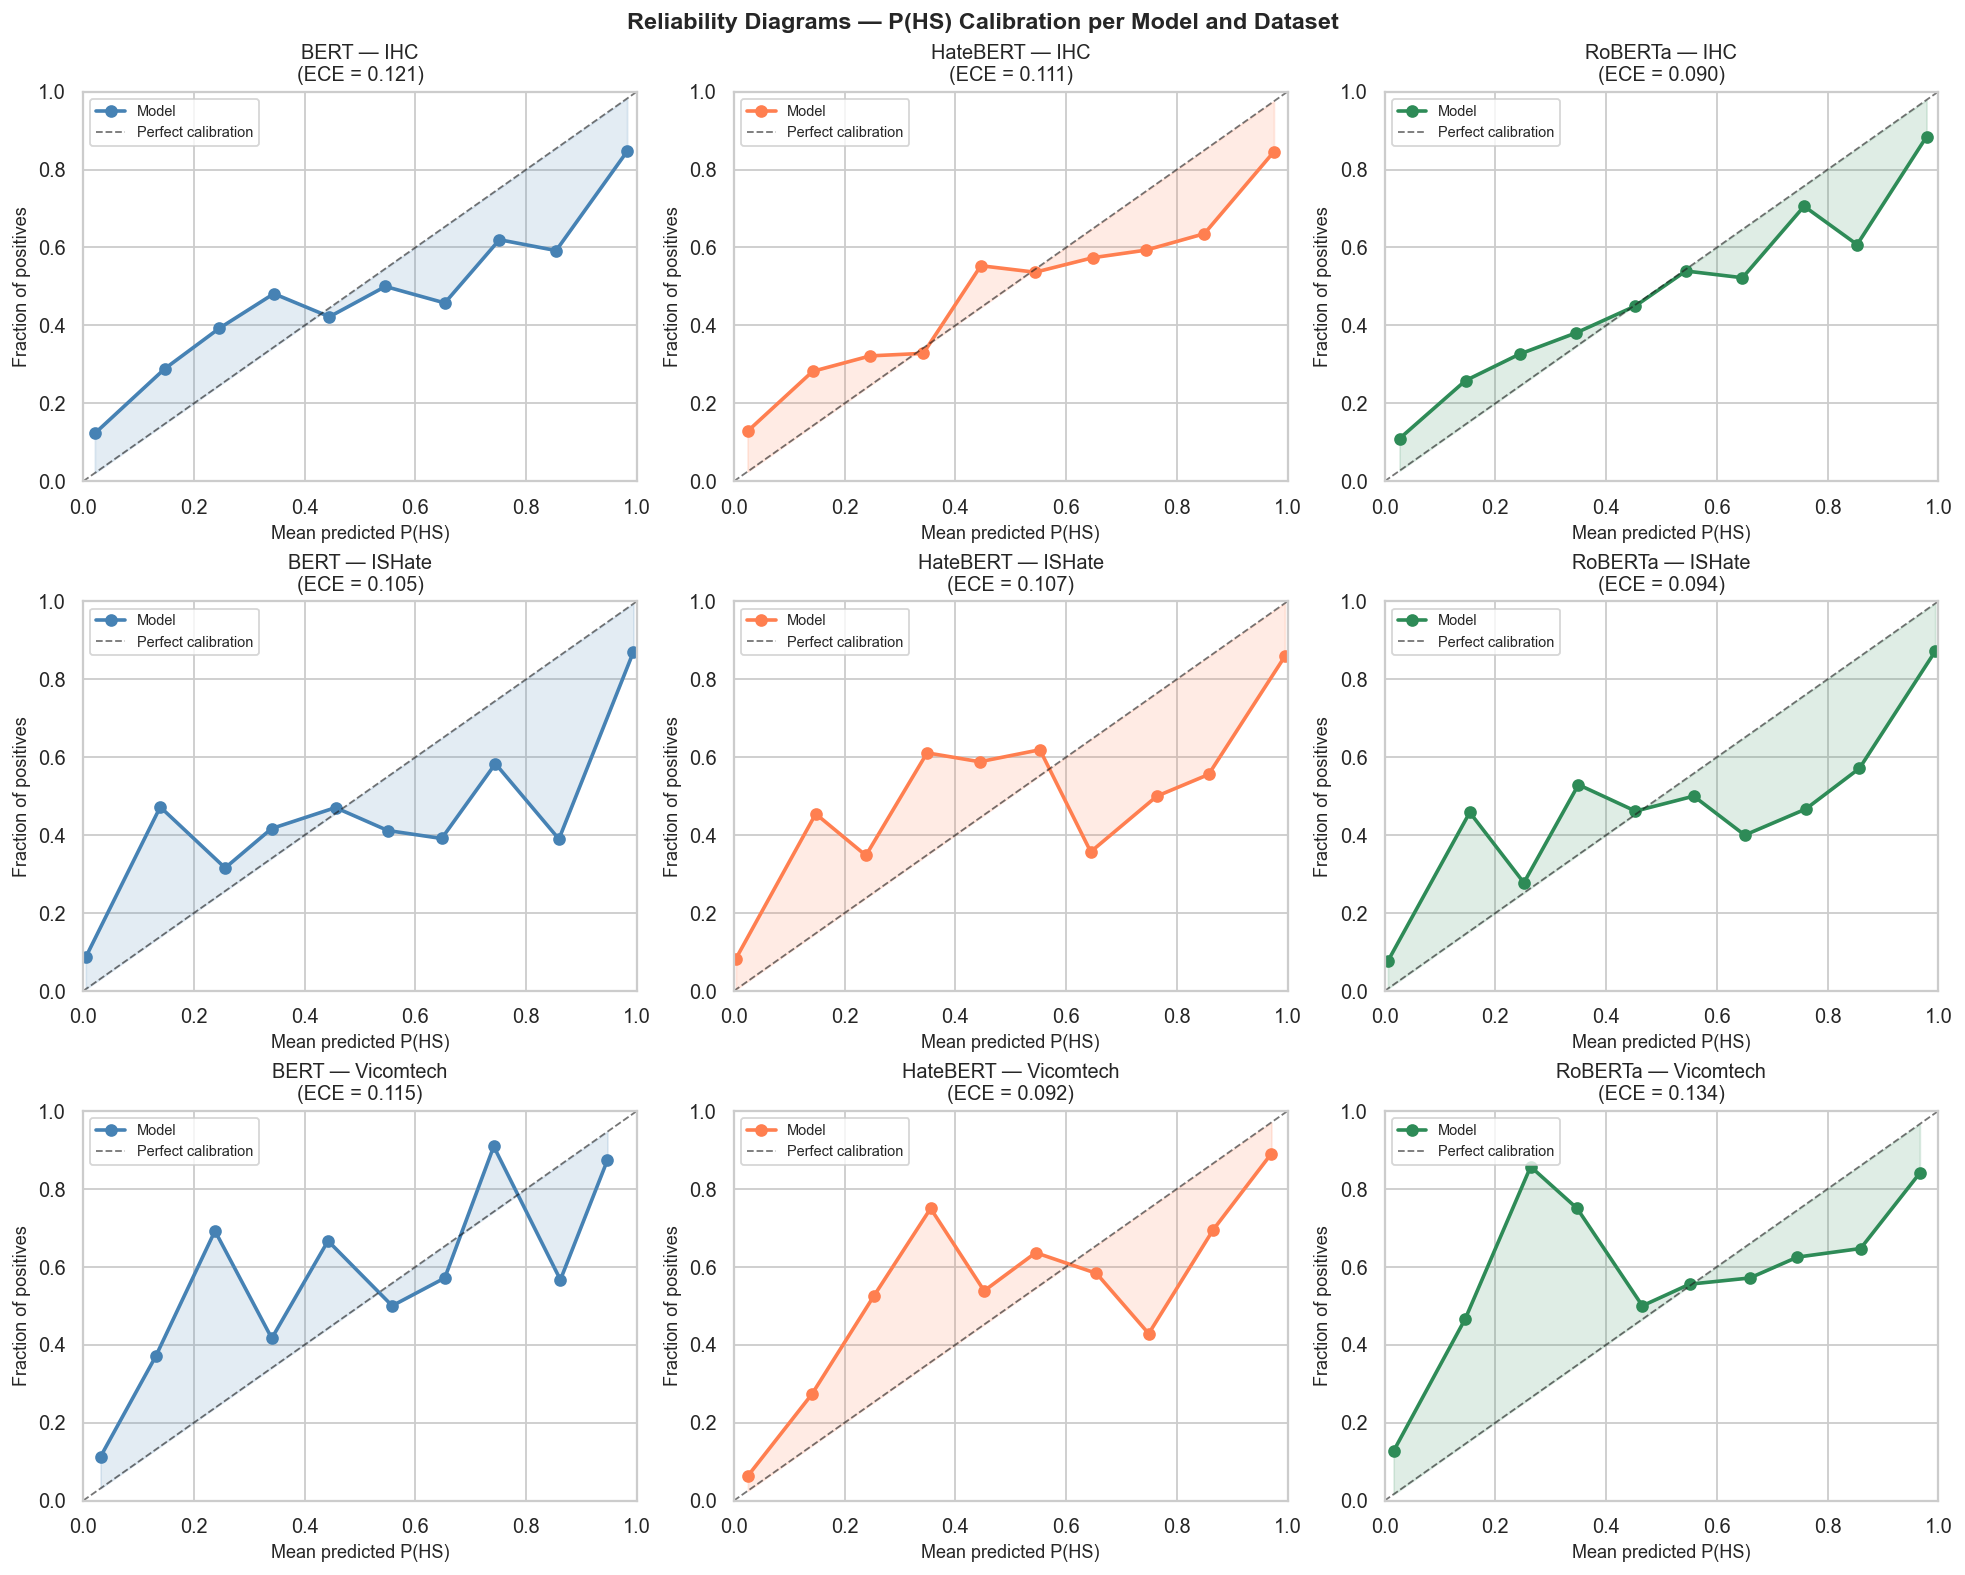

In [99]:
fig, axes = plt.subplots(len(MODELS), len(DATASETS_CFG), figsize=(5*len(DATASETS_CFG), 4*len(MODELS)), constrained_layout=True)
fig.suptitle('Reliability Diagrams — P(HS) Calibration per Model and Dataset', fontsize=13, fontweight='bold')

for ax, ((model_name, dataset_name), r) in zip(axes.flat, all_results.items()):
    frac_pos, mean_pred = calibration_curve(r['labels'], r['hs_prob'], n_bins=10, strategy='uniform')
    ece = compute_ece(r['labels'], r['hs_prob'])
    color = MODEL_COLOR[model_name]

    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=2, ms=6, label='Model')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Perfect calibration')
    ax.fill_between(mean_pred, frac_pos, mean_pred, alpha=0.15, color=color)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f'{MODEL_SHORT[model_name]} — {dataset_name}\n(ECE = {ece:.3f})')
    ax.set_xlabel('Mean predicted P(HS)')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=8)

plt.savefig('fig01_reliability_diagrams.png', bbox_inches='tight')
plt.show()

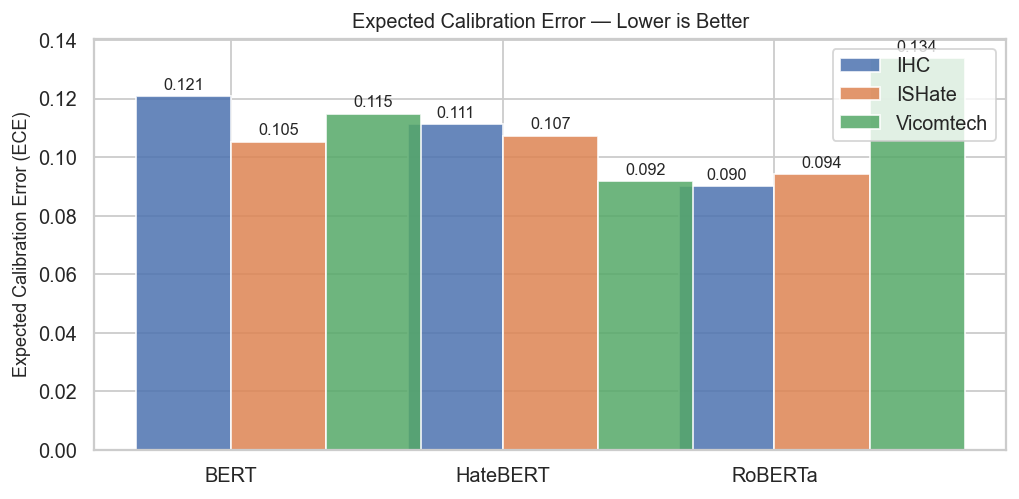

In [128]:
ece_data = {(m, d): compute_ece(r['labels'], r['hs_prob'])
            for (m, d), r in all_results.items()}

model_list = list(MODELS.keys())
x = np.arange(len(model_list))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
for i, dataset_name in enumerate(list(DATASETS_CFG.keys())):
    eces = [ece_data[(m, dataset_name)] for m in model_list]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, eces, width, label=dataset_name,
                  color=DATASET_COLOR[dataset_name], alpha=0.85)
    ax.bar_label(bars, fmt='{:.3f}', fontsize=9, padding=2)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_SHORT[m] for m in model_list])
ax.set_ylabel('Expected Calibration Error (ECE)')
ax.set_title('Expected Calibration Error — Lower is Better')
ax.legend()
plt.tight_layout()
plt.savefig('fig02_ece_bar.png', bbox_inches='tight')
plt.show()

### 4.1 After Temperature Scaling — Before / After Comparison

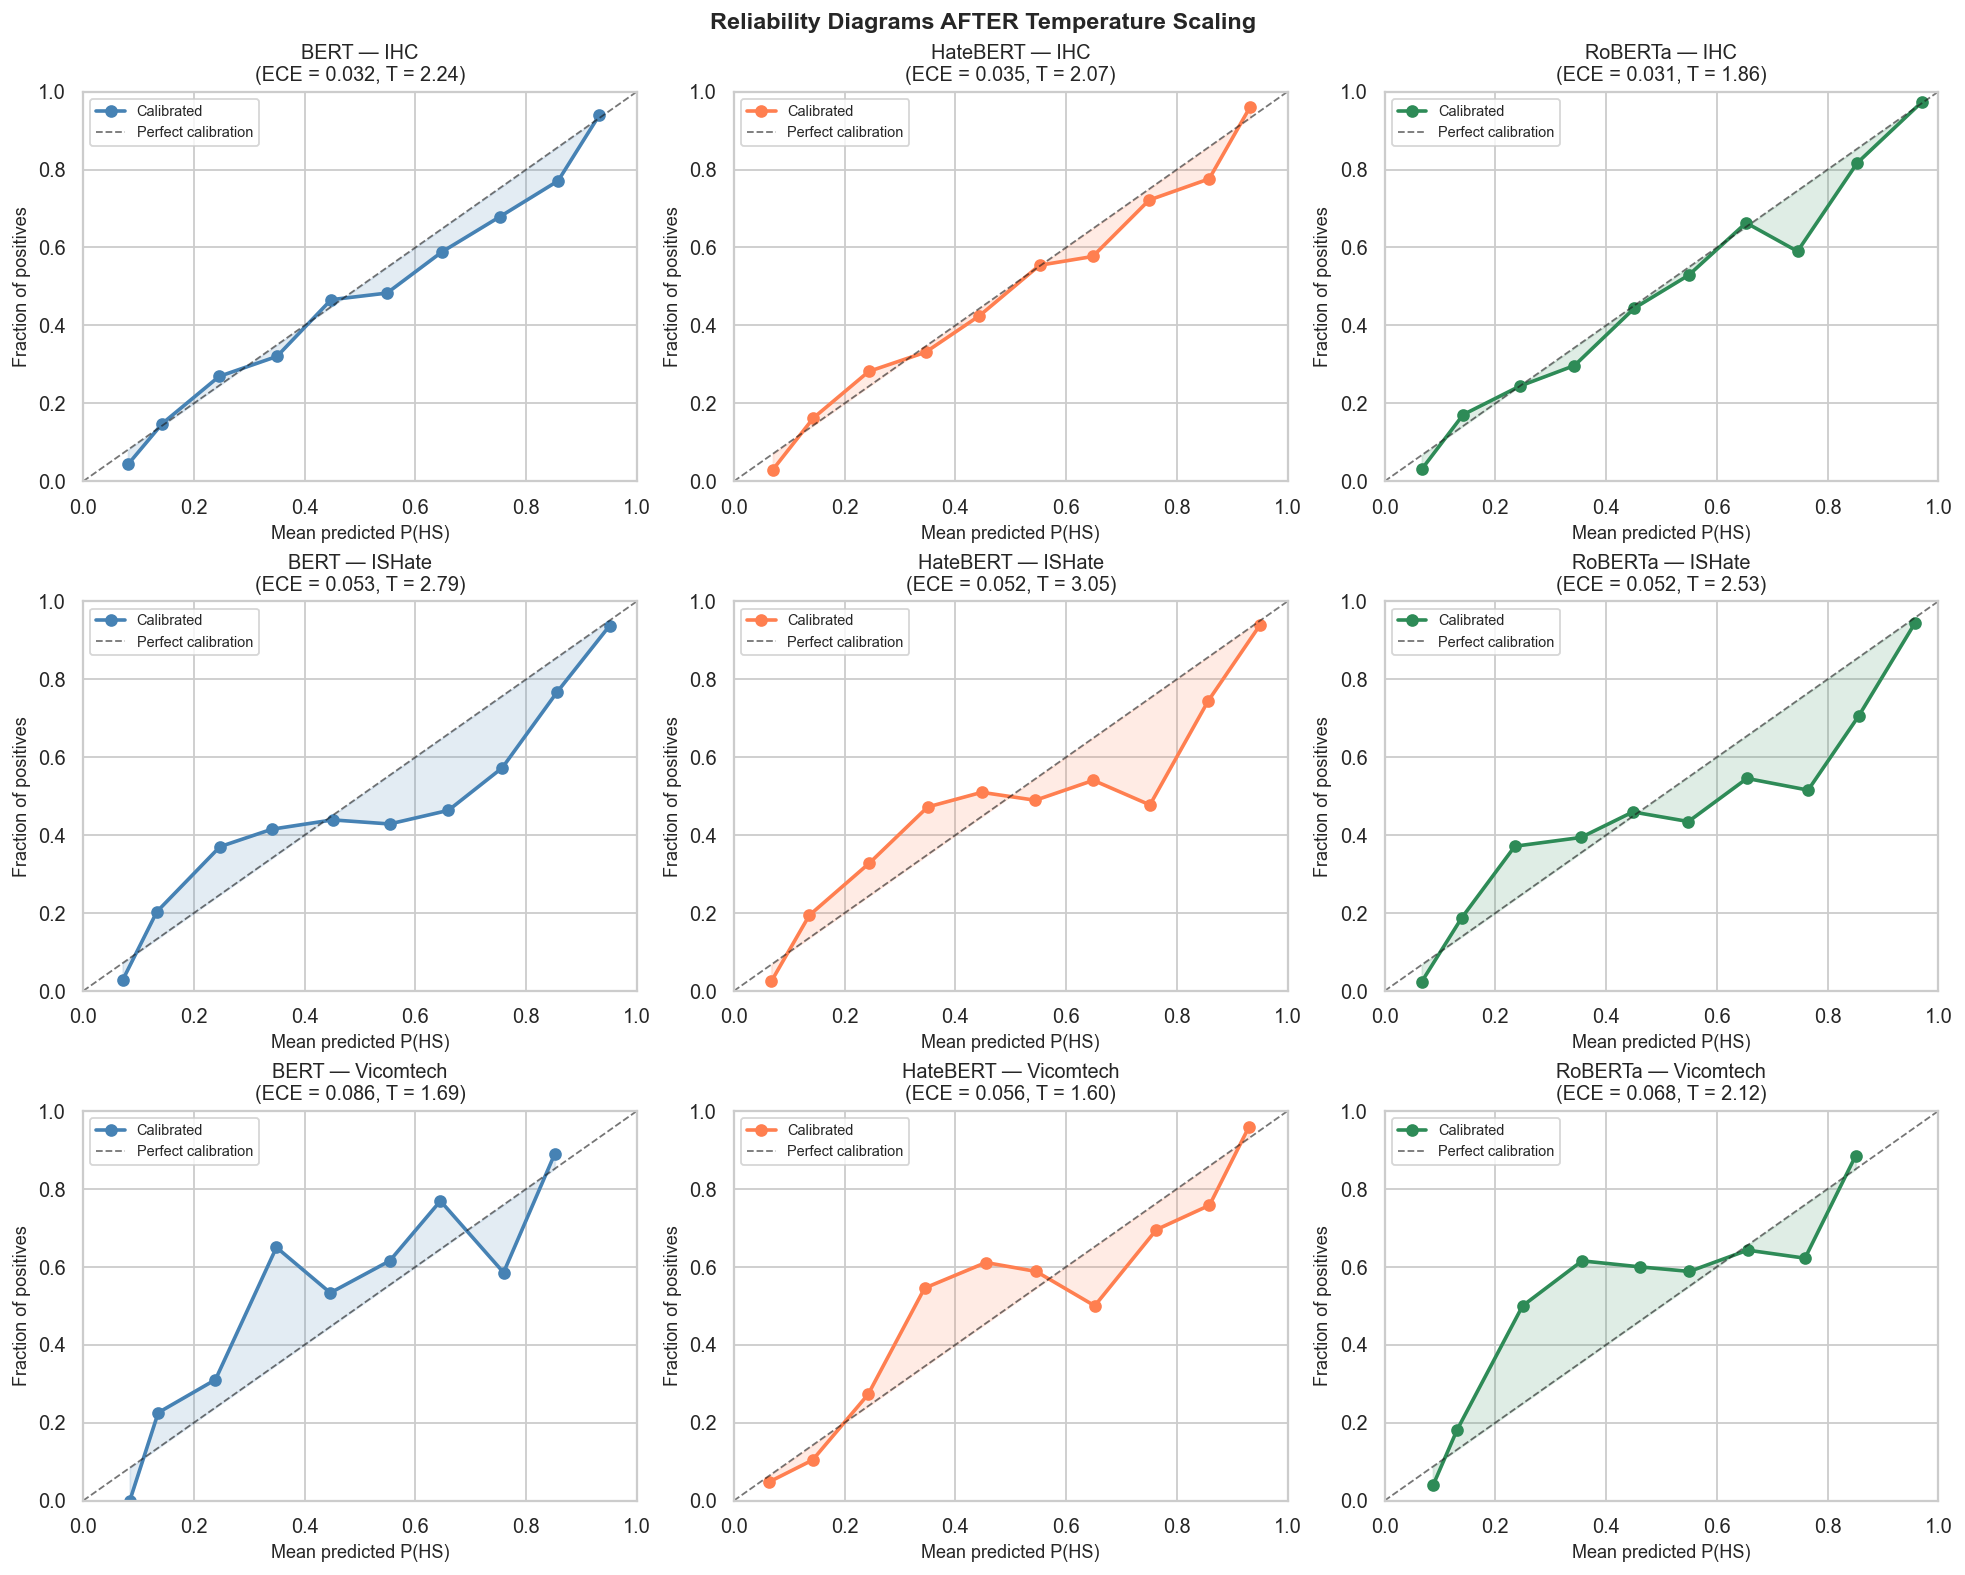

In [101]:
fig, axes = plt.subplots(len(MODELS), len(DATASETS_CFG), figsize=(5*len(DATASETS_CFG), 4*len(MODELS)), constrained_layout=True)
fig.suptitle('Reliability Diagrams AFTER Temperature Scaling', fontsize=13, fontweight='bold')

for ax, ((model_name, dataset_name), r) in zip(axes.flat, all_results.items()):
    frac_pos, mean_pred = calibration_curve(r['labels'], r['hs_prob_cal'], n_bins=10, strategy='uniform')
    ece = compute_ece(r['labels'], r['hs_prob_cal'])
    color = MODEL_COLOR[model_name]

    ax.plot(mean_pred, frac_pos, 'o-', color=color, lw=2, ms=6, label='Calibrated')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Perfect calibration')
    ax.fill_between(mean_pred, frac_pos, mean_pred, alpha=0.15, color=color)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f'{MODEL_SHORT[model_name]} — {dataset_name}\n(ECE = {ece:.3f}, T = {r["T"]:.2f})')
    ax.set_xlabel('Mean predicted P(HS)')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=8)

plt.savefig('fig02b_reliability_calibrated.png', bbox_inches='tight')
plt.show()

KeyError: 'Vicomtech'

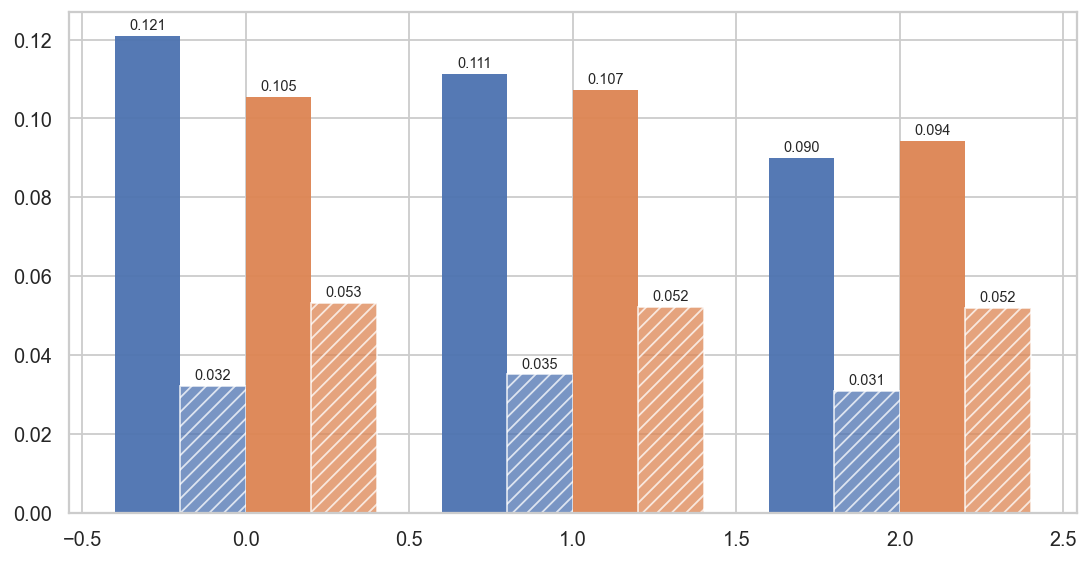

In [102]:
model_list = list(MODELS.keys())
x = np.arange(len(model_list))
width = 0.20

fig, ax = plt.subplots(figsize=(10, 5))

for i, dataset_name in enumerate(list(DATASETS_CFG.keys())):
    for j, calibrated in enumerate([False, True]):
        key = 'hs_prob_cal' if calibrated else 'hs_prob'
        eces = [compute_ece(all_results[(m, dataset_name)]['labels'],
                            all_results[(m, dataset_name)][key])
                for m in model_list]
        offset = (i * 2 + j - 1.5) * width
        hatch = '///' if calibrated else ''
        label = f'{dataset_name} {"calibrated" if calibrated else "raw"}'
        bars = ax.bar(x + offset, eces, width, label=label,
                      color=DATASET_COLOR[dataset_name], alpha=0.75 if calibrated else 0.95,
                      hatch=hatch, edgecolor='white' if calibrated else 'none')
        ax.bar_label(bars, fmt='{:.3f}', fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_SHORT[m] for m in model_list])
ax.set_ylabel('Expected Calibration Error (ECE)')
ax.set_title('ECE Before vs. After Temperature Scaling — Lower is Better\n(hatched = calibrated)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig02c_ece_before_after.png', bbox_inches='tight')
plt.show()

In [103]:
rows_cal = []
for (model_name, dataset_name), r in all_results.items():
    conf_cal = r['confidence_cal']
    gap_raw  = r['confidence'][r['correct']].mean() - r['confidence'][~r['correct']].mean()
    gap_cal  = conf_cal[r['correct']].mean() - conf_cal[~r['correct']].mean()
    rows_cal.append({
        'Model':            MODEL_SHORT[model_name],
        'Dataset':          dataset_name,
        'T':                r['T'],
        'ConfGap(raw)':     gap_raw,
        'ConfGap(cal)':     gap_cal,
        'Conf(wrong)(raw)': r['confidence'][~r['correct']].mean(),
        'Conf(wrong)(cal)': conf_cal[~r['correct']].mean(),
    })

cal_df = pd.DataFrame(rows_cal)
for dataset_name in list(DATASETS_CFG.keys()):
    sub = cal_df[cal_df['Dataset'] == dataset_name].set_index('Model').drop(columns='Dataset')
    display(
        sub.style
        .format({'T': '{:.3f}', 'ConfGap(raw)': '{:.3f}', 'ConfGap(cal)': '{:.3f}',
                 'Conf(wrong)(raw)': '{:.3f}', 'Conf(wrong)(cal)': '{:.3f}'})
        .highlight_max(axis=0, subset=['ConfGap(raw)', 'ConfGap(cal)'],
                       props='font-weight: bold; background-color: #d4f1d4')
        .highlight_min(axis=0, subset=['Conf(wrong)(raw)', 'Conf(wrong)(cal)'],
                       props='background-color: #ffe0e0')
        .set_caption(f'{dataset_name} — Temperature Scaling Summary')
    )

,T,ConfGap(raw),ConfGap(cal),Conf(wrong)(raw),Conf(wrong)(cal)
Model,,,,,
BERT,2.237,0.099,0.112,0.838,0.719
HateBERT,2.071,0.090,0.105,0.838,0.723
RoBERTa,1.863,0.108,0.122,0.811,0.715


,T,ConfGap(raw),ConfGap(cal),Conf(wrong)(raw),Conf(wrong)(cal)
Model,,,,,
BERT,2.787,0.053,0.108,0.937,0.799
HateBERT,3.047,0.050,0.111,0.940,0.796
RoBERTa,2.535,0.043,0.097,0.948,0.820


,T,ConfGap(raw),ConfGap(cal),Conf(wrong)(raw),Conf(wrong)(cal)
Model,,,,,
BERT,1.693,0.086,0.088,0.841,0.751
HateBERT,1.600,0.136,0.143,0.800,0.729
RoBERTa,2.120,0.083,0.094,0.873,0.750


## 5. Confidence Distributions

For a useful threshold, correctly-classified examples should cluster near 1.0 and errors near 0.5. A large overlap means confidence does not reliably signal correctness.

**Note**: Binary softmax always yields confidence ≥ 0.5, so X-axes start there.

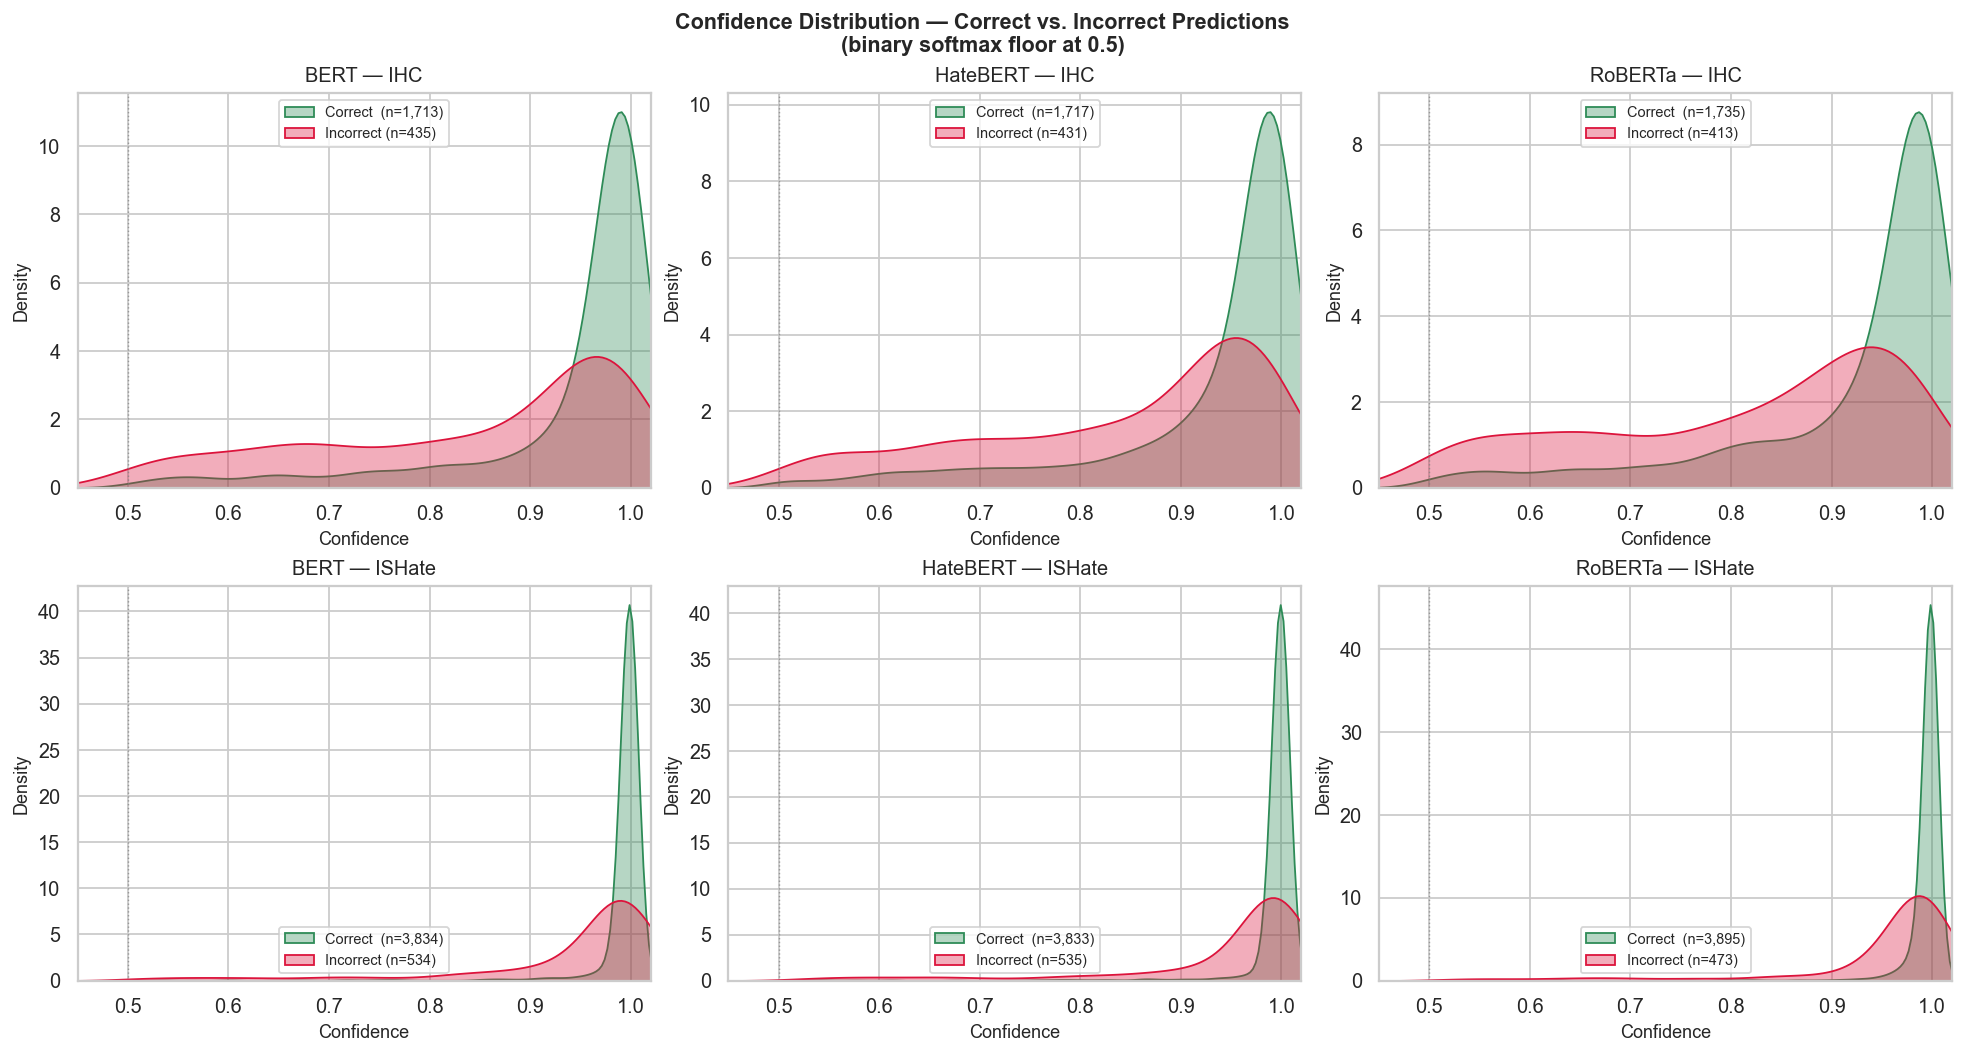

In [104]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
fig.suptitle('Confidence Distribution — Correct vs. Incorrect Predictions\n(binary softmax floor at 0.5)', fontsize=12, fontweight='bold')

for ax, ((model_name, dataset_name), r) in zip(axes.flat, all_results.items()):
    conf_ok   = r['confidence'][r['correct']]
    conf_bad  = r['confidence'][~r['correct']]

    sns.kdeplot(conf_ok,  ax=ax, color='seagreen', fill=True, alpha=0.35,
                label=f'Correct  (n={len(conf_ok):,})')
    if len(conf_bad) > 2:
        sns.kdeplot(conf_bad, ax=ax, color='crimson', fill=True, alpha=0.35,
                    label=f'Incorrect (n={len(conf_bad):,})')
    ax.axvline(0.5, color='gray', lw=0.8, linestyle=':', alpha=0.7)
    ax.set_xlim(0.45, 1.02)
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Density')
    ax.set_title(f'{MODEL_SHORT[model_name]} — {dataset_name}')
    ax.legend(fontsize=8)

plt.savefig('fig03_confidence_kde.png', bbox_inches='tight')
plt.show()

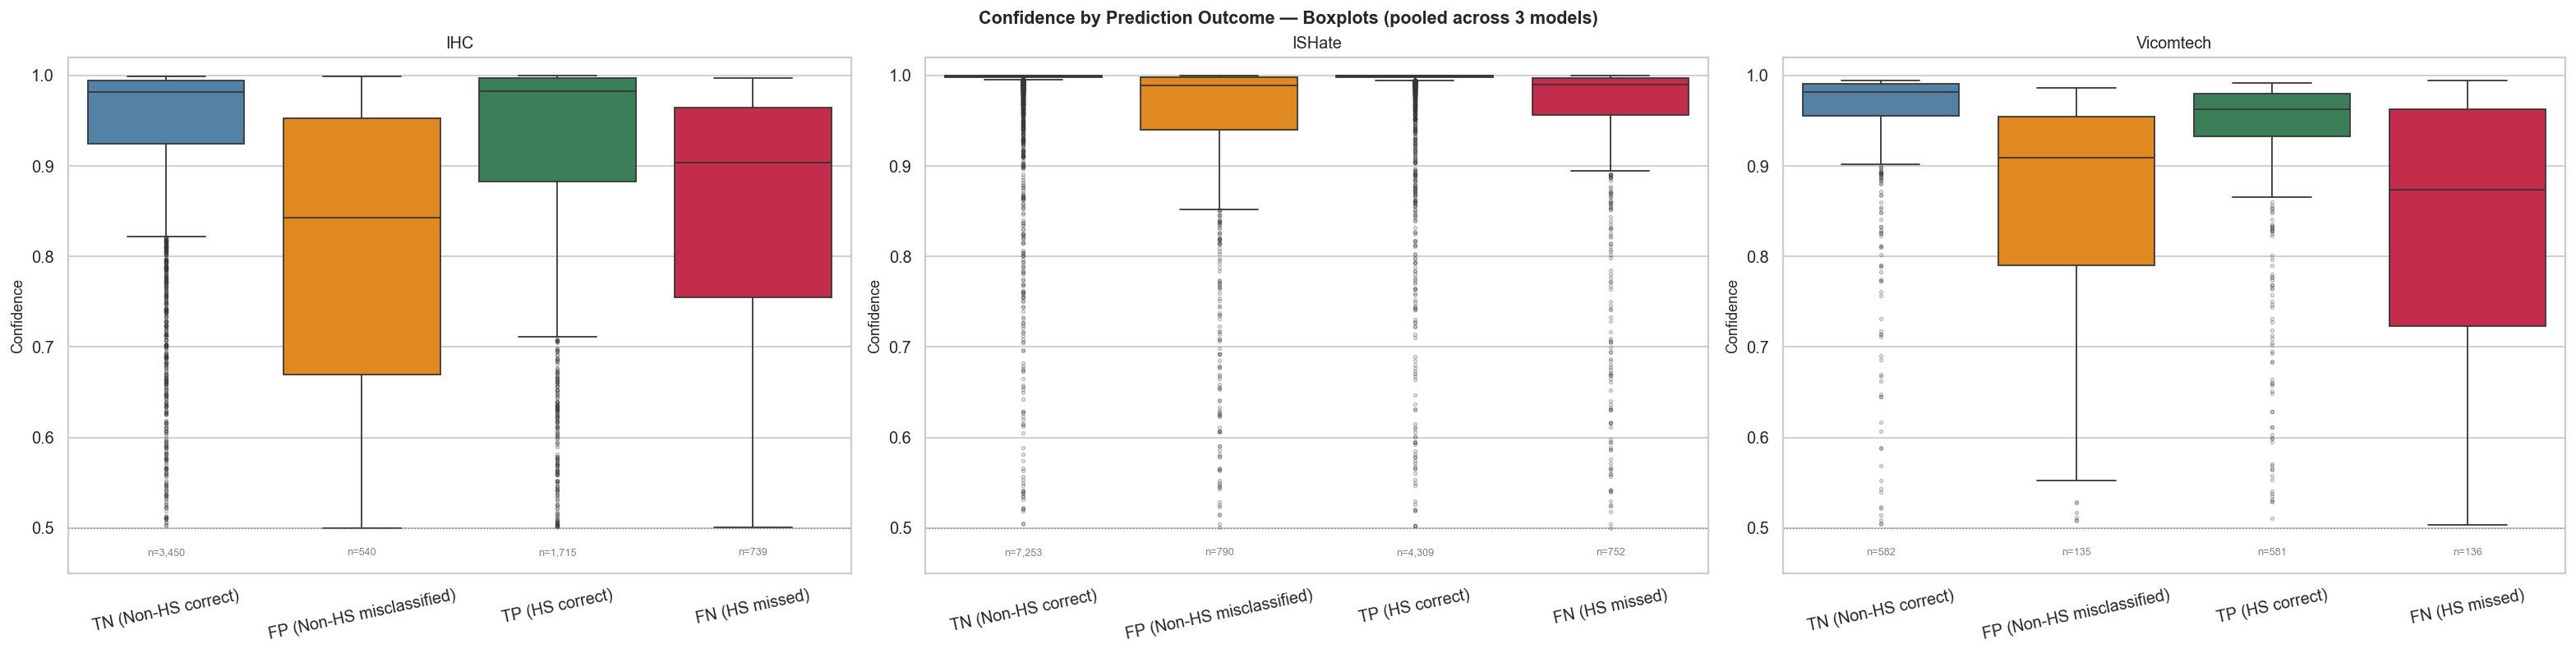

In [105]:
fig, axes = plt.subplots(1, len(DATASETS_CFG), figsize=(8*len(DATASETS_CFG), 6), constrained_layout=True)
fig.suptitle('Confidence by Prediction Outcome — Boxplots (pooled across 3 models)', fontsize=12, fontweight='bold')

quadrant_order   = ['TN (Non-HS correct)', 'FP (Non-HS misclassified)', 'TP (HS correct)', 'FN (HS missed)']
quadrant_palette = {
    'TN (Non-HS correct)':     'steelblue',
    'FP (Non-HS misclassified)': 'darkorange',
    'TP (HS correct)':          'seagreen',
    'FN (HS missed)':           'crimson',
}

for ax, dataset_name in zip(axes, list(DATASETS_CFG.keys())):
    records = []
    for model_name in MODELS:
        r = all_results[(model_name, dataset_name)]
        tl = r['labels']; pl = r['predicted']; cf = r['confidence']
        quad = np.where((tl==0)&(pl==0), 'TN (Non-HS correct)',
               np.where((tl==0)&(pl==1), 'FP (Non-HS misclassified)',
               np.where((tl==1)&(pl==1), 'TP (HS correct)',
                                         'FN (HS missed)')))
        for q, c in zip(quad, cf):
            records.append({'Outcome': q, 'Confidence': c})

    df_q = pd.DataFrame(records)
    sns.boxplot(data=df_q, x='Outcome', y='Confidence', order=quadrant_order,
                palette=quadrant_palette, ax=ax, flierprops={'markersize': 2, 'alpha': 0.3})
    ax.set_ylim(0.45, 1.02)
    ax.set_title(dataset_name)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=12)
    ax.axhline(0.5, color='gray', lw=0.8, linestyle=':')
    counts = df_q.groupby('Outcome').size().reindex(quadrant_order)
    for i, cnt in enumerate(counts):
        ax.text(i, 0.47, f'n={cnt:,}', ha='center', fontsize=7, color='gray')

plt.savefig('fig04_box_quadrant.png', bbox_inches='tight')
plt.show()

## 6. Selective Prediction — Threshold Sweep

At confidence threshold *t*, we retain only examples where `confidence >= t` and forward the rest to RAG. As *t* rises:
- **Accuracy on retained examples** should increase (we keep only high-confidence predictions)
- **Coverage** (fraction retained) falls

The crossing point of these curves is the natural operating point.

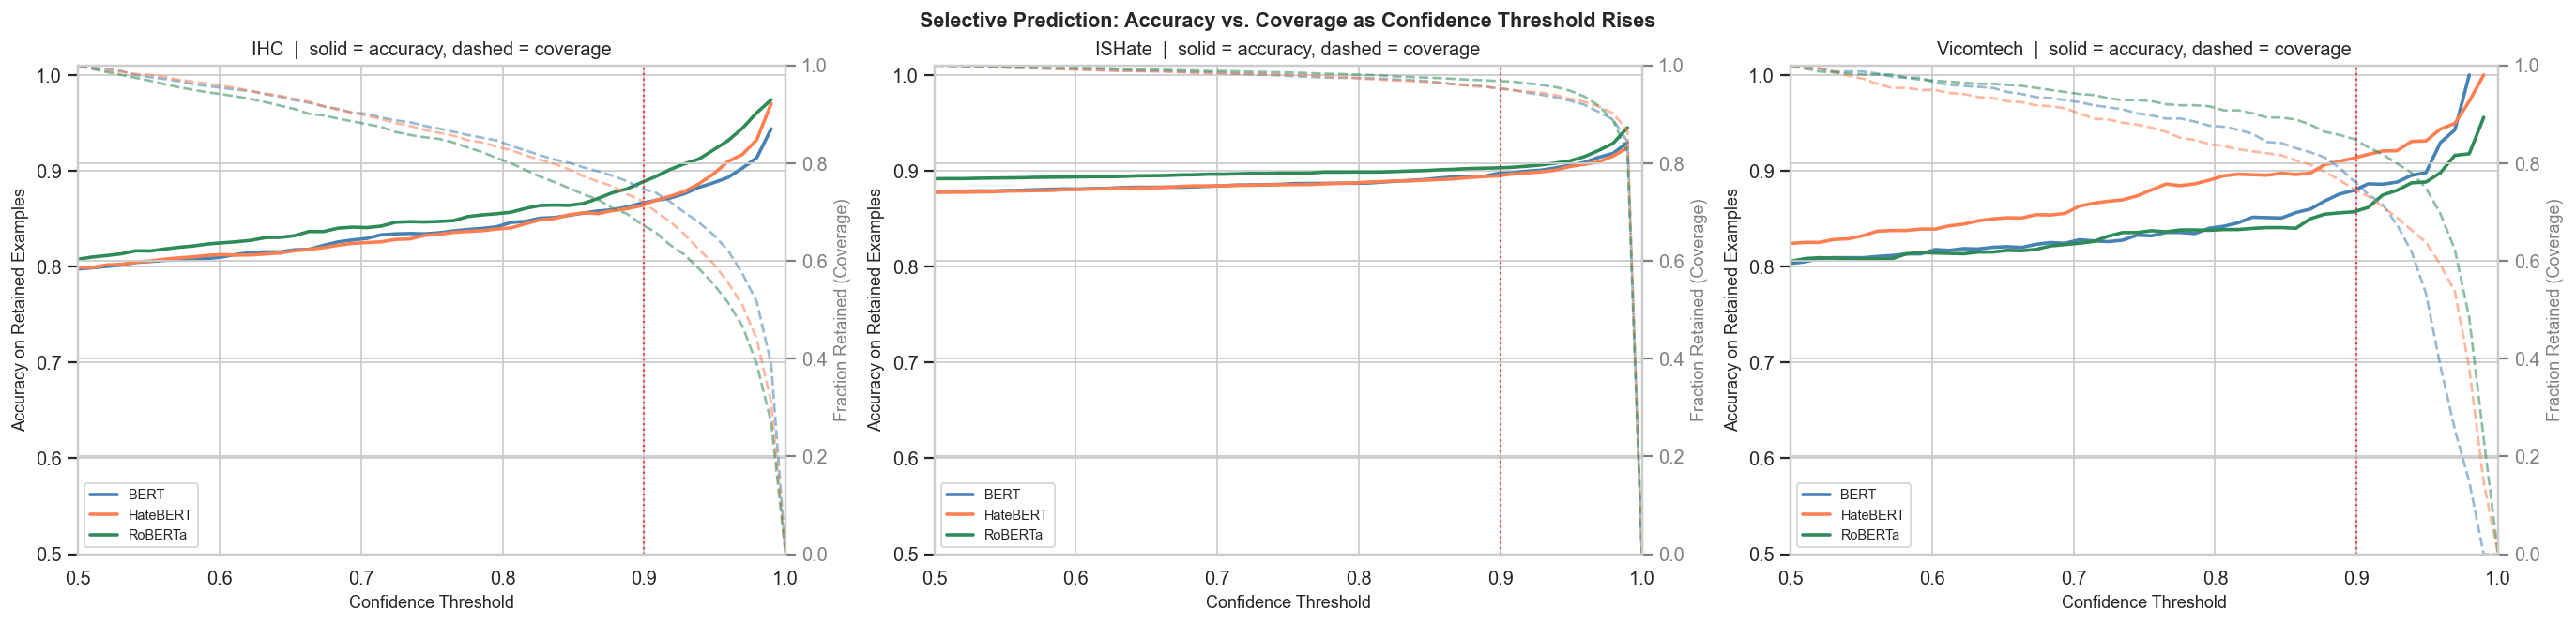

In [106]:
fig, axes = plt.subplots(1, len(DATASETS_CFG), figsize=(7*len(DATASETS_CFG), 5), constrained_layout=True)
fig.suptitle('Selective Prediction: Accuracy vs. Coverage as Confidence Threshold Rises', fontsize=12, fontweight='bold')

for ax, dataset_name in zip(axes, list(DATASETS_CFG.keys())):
    ax2 = ax.twinx()

    for model_name in MODELS:
        r     = all_results[(model_name, dataset_name)]
        color = MODEL_COLOR[model_name]
        short = MODEL_SHORT[model_name]

        accs, coverages = [], []
        for t in THRESHOLDS_SWEEP:
            mask = r['confidence'] >= t
            if mask.sum() == 0:
                accs.append(np.nan)
                coverages.append(0.0)
            else:
                accs.append((r['predicted'][mask] == r['labels'][mask]).mean())
                coverages.append(mask.mean())

        ax.plot(THRESHOLDS_SWEEP, accs,      color=color, lw=2,   label=short)
        ax2.plot(THRESHOLDS_SWEEP, coverages, color=color, lw=1.5, linestyle='--', alpha=0.55)

    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Accuracy on Retained Examples')
    ax2.set_ylabel('Fraction Retained (Coverage)', color='gray')
    ax2.tick_params(axis='y', colors='gray')
    ax2.yaxis.label.set_color('gray')
    ax.set_title(f'{dataset_name}  |  solid = accuracy, dashed = coverage')
    ax.set_xlim(0.5, 1.0); ax.set_ylim(0.5, 1.01)
    ax2.set_ylim(0, 1)
    ax.legend(loc='lower left', fontsize=8)
    ax.axvline(0.90, color='red', lw=1.2, linestyle=':', alpha=0.7, label='t=0.90')

plt.savefig('fig05_selective_prediction.png', bbox_inches='tight')
plt.show()

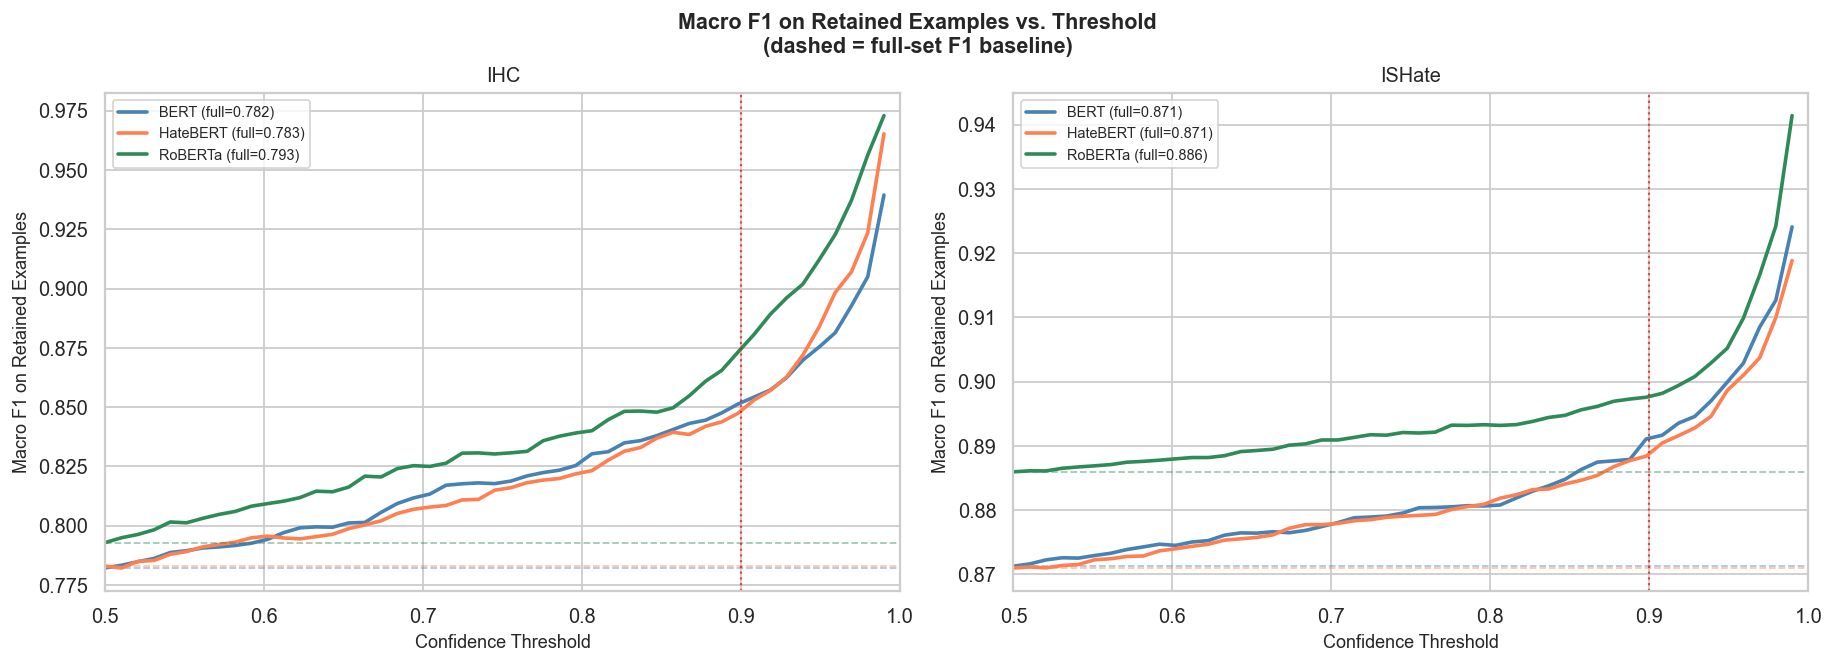

In [ ]:
fig, axes = plt.subplots(1, len(DATASETS_CFG), figsize=(7*len(DATASETS_CFG), 5), constrained_layout=True)
fig.suptitle('Macro F1 on Retained Examples vs. Threshold\n(dashed = full-set F1 baseline)', fontsize=12, fontweight='bold')

for ax, dataset_name in zip(axes, list(DATASETS_CFG.keys())):
    for model_name in MODELS:
        r        = all_results[(model_name, dataset_name)]
        color    = MODEL_COLOR[model_name]
        short    = MODEL_SHORT[model_name]
        full_f1  = f1_score(r['labels'], r['predicted'], average='macro', zero_division=0)

        f1s = []
        for t in THRESHOLDS_SWEEP:
            mask = r['confidence'] >= t
            if mask.sum() < 10:
                f1s.append(np.nan)
            else:
                f1s.append(f1_score(r['labels'][mask], r['predicted'][mask], average='macro', zero_division=0))

        ax.plot(THRESHOLDS_SWEEP, f1s, color=color, lw=2, label=f'{short} (full={full_f1:.3f})')
        ax.axhline(full_f1, color=color, lw=1, linestyle='--', alpha=0.45)

    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Macro F1 on Retained Examples')
    ax.set_title(dataset_name)
    ax.set_xlim(0.5, 1.0)
    ax.legend(fontsize=8)
    ax.axvline(0.90, color='red', lw=1.2, linestyle=':', alpha=0.7)

plt.savefig('fig06_f1_vs_threshold.png', bbox_inches='tight')
plt.show()

### 6.1 Calibrated Threshold Analysis

Using calibrated confidence scores (after temperature scaling). The key question: does the threshold become effective for ISHate after calibration?

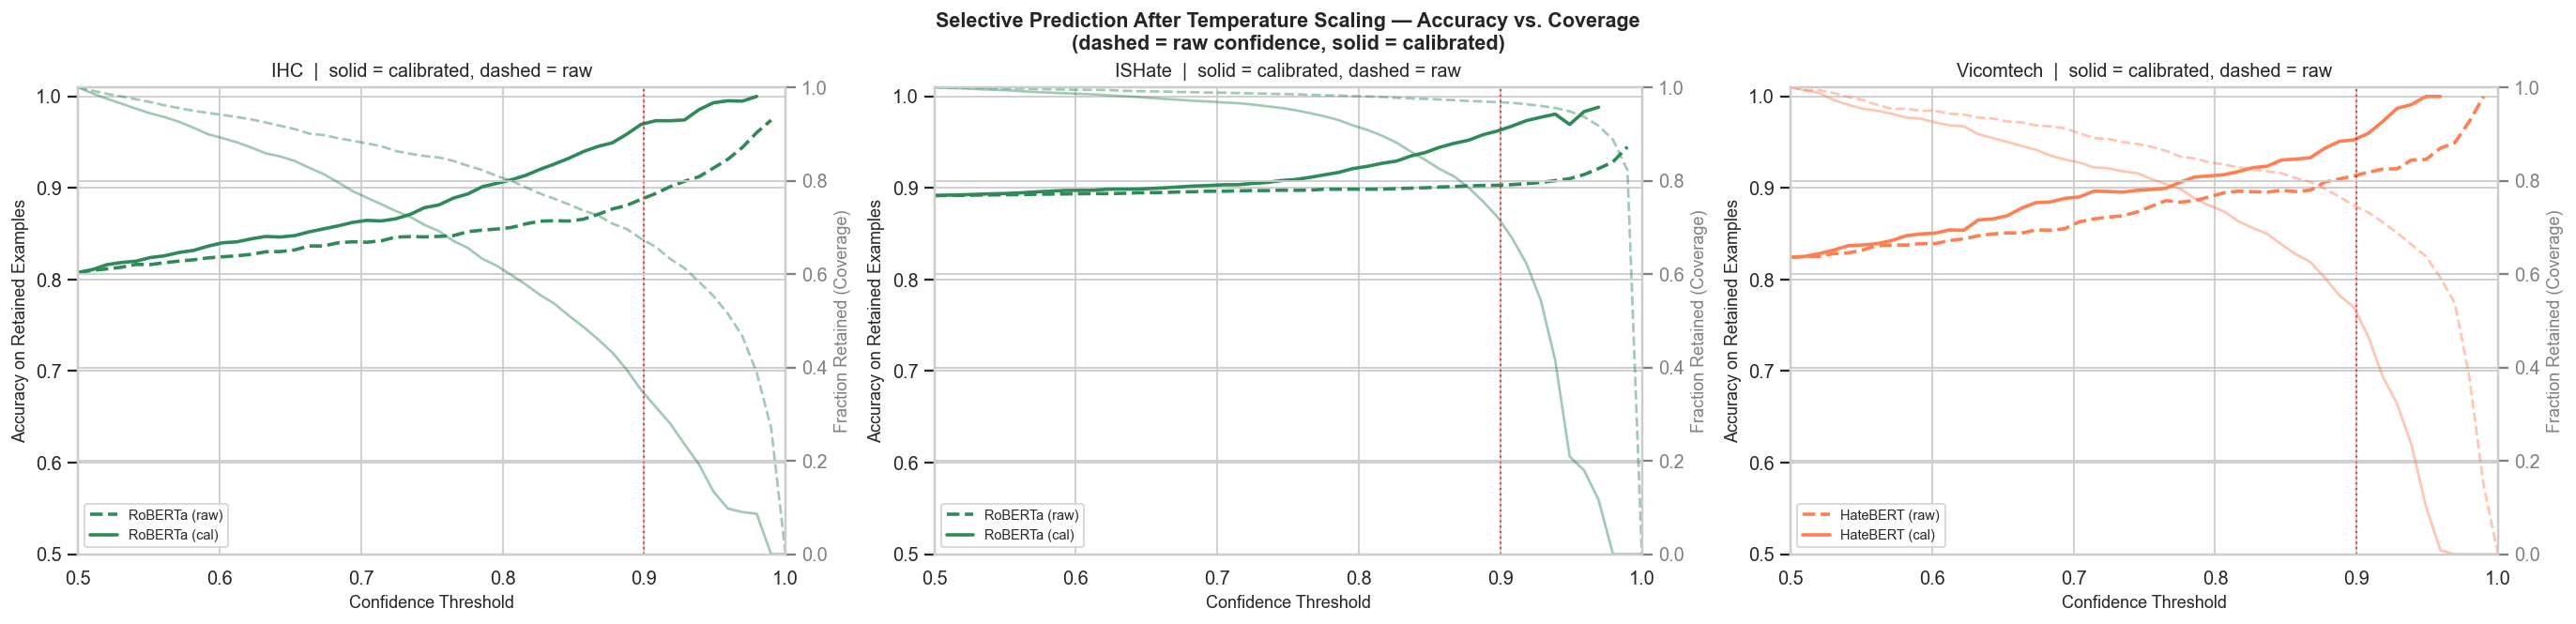

In [107]:
fig, axes = plt.subplots(1, len(DATASETS_CFG), figsize=(7*len(DATASETS_CFG), 5), constrained_layout=True)
fig.suptitle('Selective Prediction After Temperature Scaling — Accuracy vs. Coverage\n(dashed = raw confidence, solid = calibrated)', fontsize=12, fontweight='bold')

for ax, dataset_name in zip(axes, list(DATASETS_CFG.keys())):
    best_model = best_models[dataset_name]
    ax2 = ax.twinx()

    for cal, ls, label_sfx in [(False, '--', ' (raw)'), (True, '-', ' (cal)')]:
        r    = all_results[(best_model, dataset_name)]
        conf = r['confidence_cal'] if cal else r['confidence']
        color = MODEL_COLOR[best_model]

        accs, coverages = [], []
        for t in THRESHOLDS_SWEEP:
            mask = conf >= t
            if mask.sum() == 0:
                accs.append(np.nan); coverages.append(0.0)
            else:
                accs.append((r['predicted'][mask] == r['labels'][mask]).mean())
                coverages.append(mask.mean())

        ax.plot(THRESHOLDS_SWEEP, accs, color=color, lw=2, linestyle=ls,
                label=f'{MODEL_SHORT[best_model]}{label_sfx}')
        ax2.plot(THRESHOLDS_SWEEP, coverages, color=color, lw=1.5,
                 linestyle=ls, alpha=0.45)

    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Accuracy on Retained Examples')
    ax2.set_ylabel('Fraction Retained (Coverage)', color='gray')
    ax2.tick_params(axis='y', colors='gray')
    ax2.yaxis.label.set_color('gray')
    ax.set_title(f'{dataset_name}  |  solid = calibrated, dashed = raw')
    ax.set_xlim(0.5, 1.0); ax.set_ylim(0.5, 1.01)
    ax2.set_ylim(0, 1)
    ax.legend(loc='lower left', fontsize=8)
    ax.axvline(0.90, color='red', lw=1.2, linestyle=':', alpha=0.7)

plt.savefig('fig05b_selective_prediction_calibrated.png', bbox_inches='tight')
plt.show()

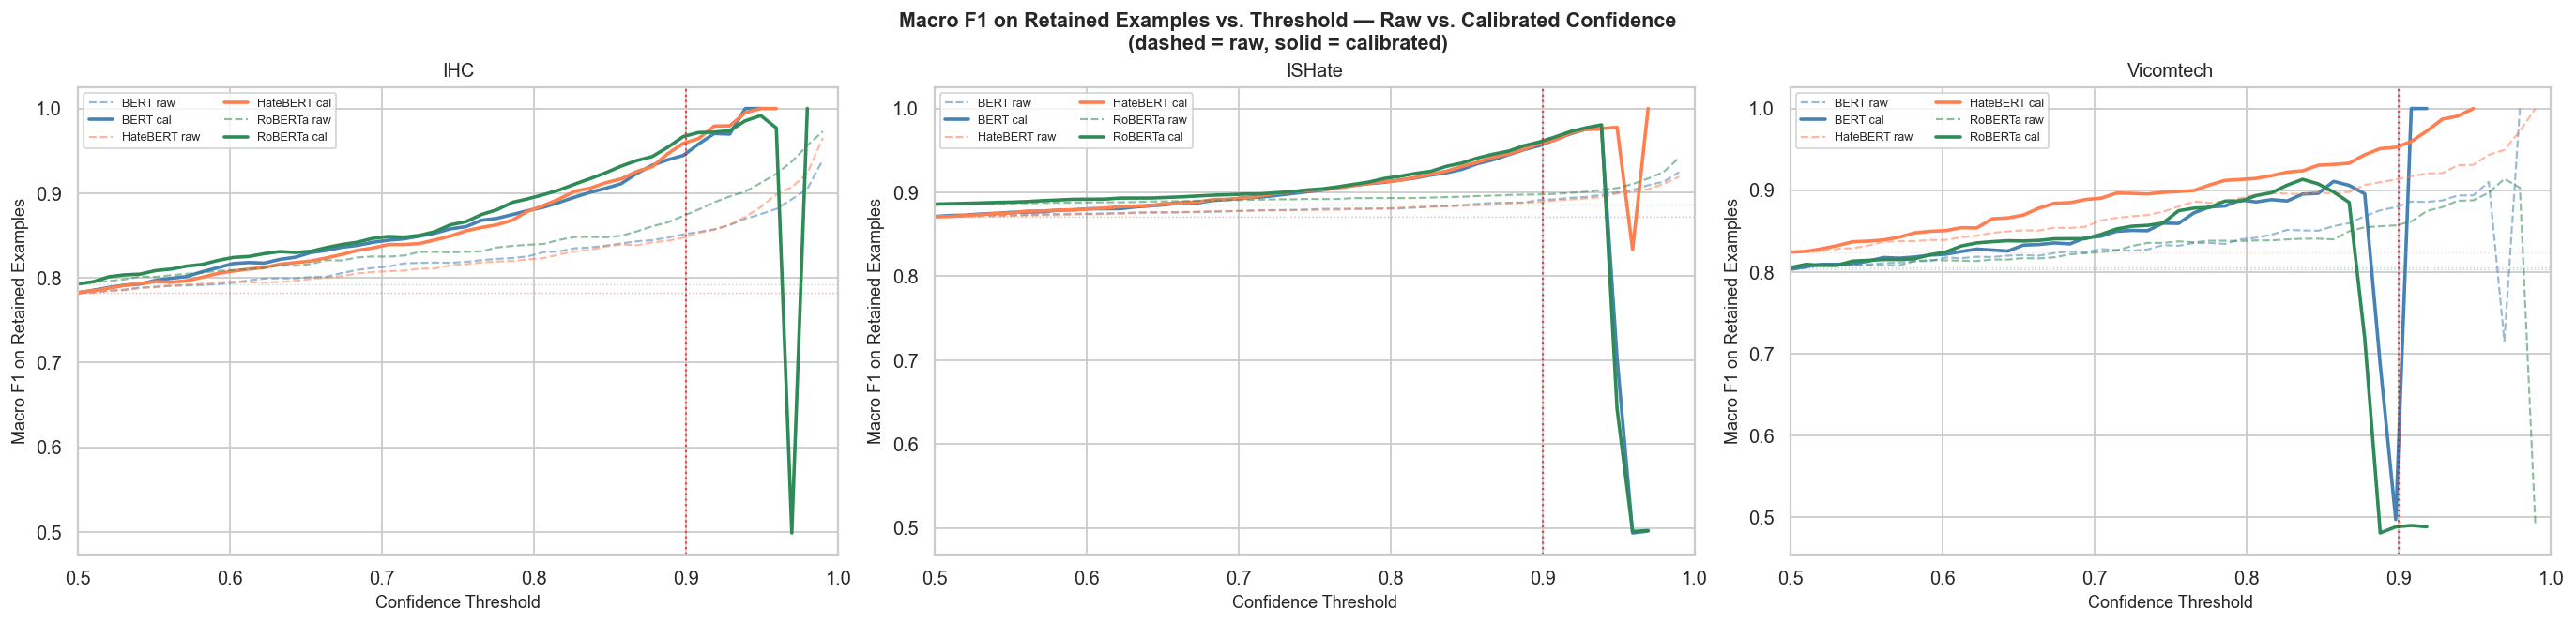

In [108]:
fig, axes = plt.subplots(1, len(DATASETS_CFG), figsize=(7*len(DATASETS_CFG), 5), constrained_layout=True)
fig.suptitle('Macro F1 on Retained Examples vs. Threshold — Raw vs. Calibrated Confidence\n(dashed = raw, solid = calibrated)', fontsize=12, fontweight='bold')

for ax, dataset_name in zip(axes, list(DATASETS_CFG.keys())):
    for model_name in MODELS:
        r       = all_results[(model_name, dataset_name)]
        color   = MODEL_COLOR[model_name]
        short   = MODEL_SHORT[model_name]
        full_f1 = f1_score(r['labels'], r['predicted'], average='macro', zero_division=0)

        for cal, ls in [(False, '--'), (True, '-')]:
            conf = r['confidence_cal'] if cal else r['confidence']
            f1s  = []
            for t in THRESHOLDS_SWEEP:
                mask = conf >= t
                if mask.sum() < 10:
                    f1s.append(np.nan)
                else:
                    f1s.append(f1_score(r['labels'][mask], r['predicted'][mask],
                                        average='macro', zero_division=0))
            lbl = f'{short} cal' if cal else f'{short} raw'
            ax.plot(THRESHOLDS_SWEEP, f1s, color=color, lw=2 if cal else 1.2,
                    linestyle=ls, label=lbl, alpha=1.0 if cal else 0.55)

        ax.axhline(full_f1, color=color, lw=0.8, linestyle=':', alpha=0.3)

    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Macro F1 on Retained Examples')
    ax.set_title(dataset_name)
    ax.set_xlim(0.5, 1.0)
    ax.legend(fontsize=7, ncol=2)
    ax.axvline(0.90, color='red', lw=1.2, linestyle=':', alpha=0.7)

plt.savefig('fig06b_f1_threshold_calibrated.png', bbox_inches='tight')
plt.show()

## 7. ROC and Precision-Recall Curves

These use `P(HS)` as a continuous discriminant score (no threshold applied). ROC-AUC measures overall discrimination; PR-AUC is more informative for imbalanced classes.

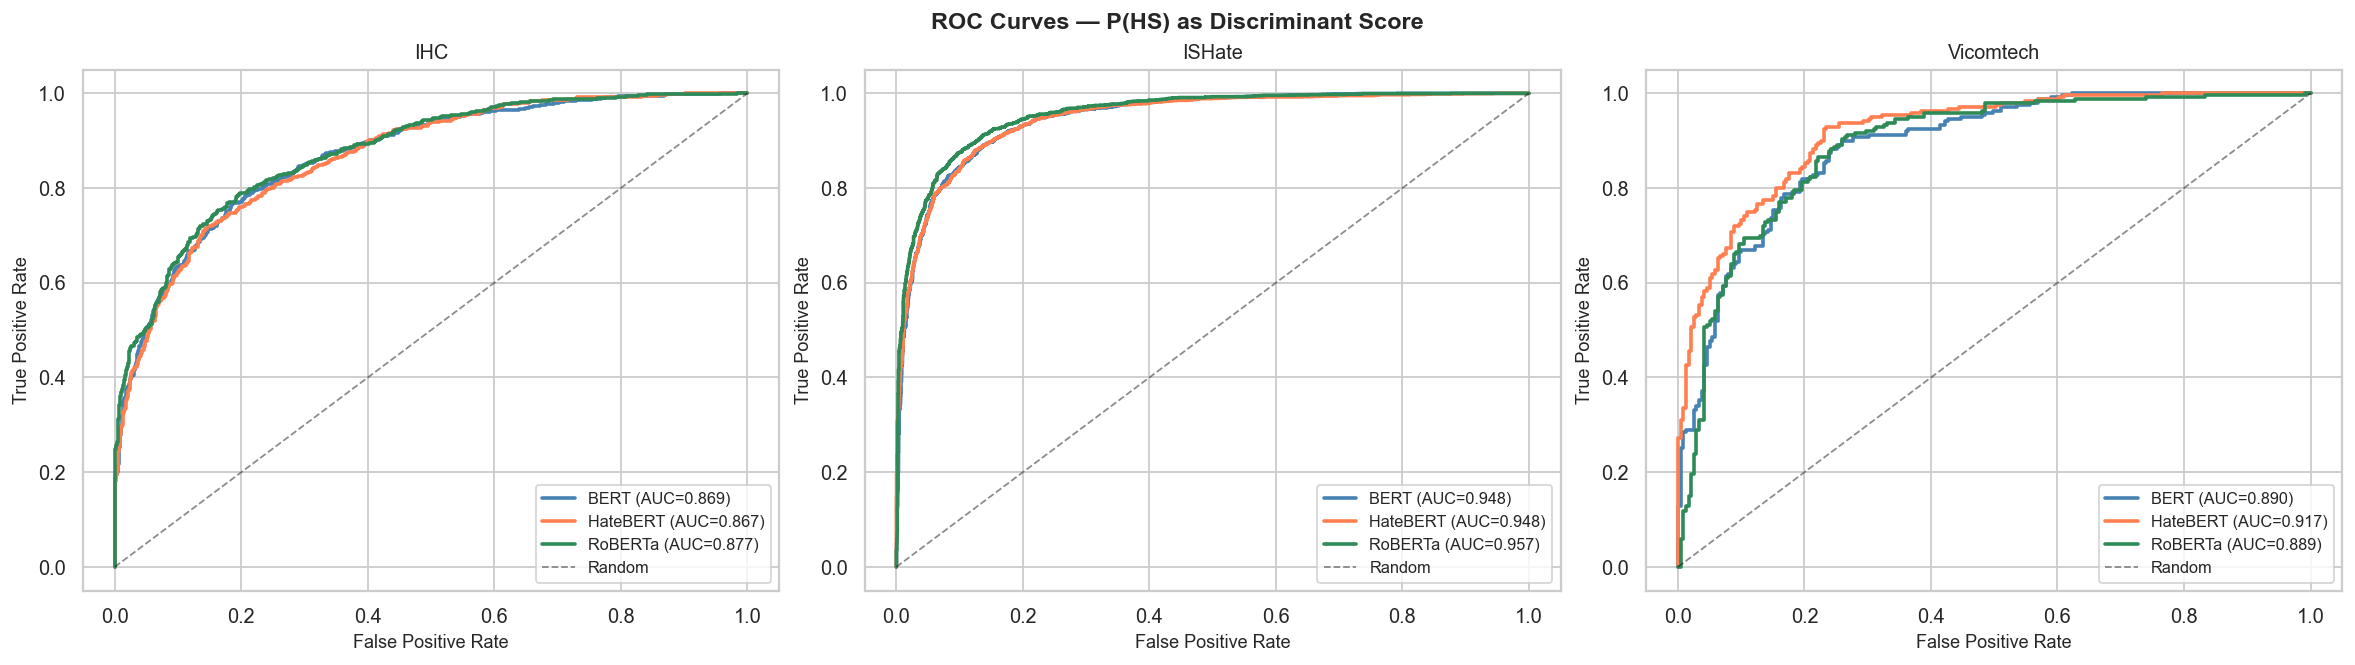

In [109]:
fig, axes = plt.subplots(1, len(DATASETS_CFG), figsize=(6*len(DATASETS_CFG), 5), constrained_layout=True)
fig.suptitle('ROC Curves — P(HS) as Discriminant Score', fontsize=13, fontweight='bold')

for ax, dataset_name in zip(axes, list(DATASETS_CFG.keys())):
    for model_name in MODELS:
        r = all_results[(model_name, dataset_name)]
        fpr, tpr, _ = roc_curve(r['labels'], r['hs_prob'])
        auc_val = roc_auc_score(r['labels'], r['hs_prob'])
        ax.plot(fpr, tpr, color=MODEL_COLOR[model_name], lw=2,
                label=f"{MODEL_SHORT[model_name]} (AUC={auc_val:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(dataset_name)
    ax.legend(fontsize=9)

plt.savefig('fig07_roc.png', bbox_inches='tight')
plt.show()

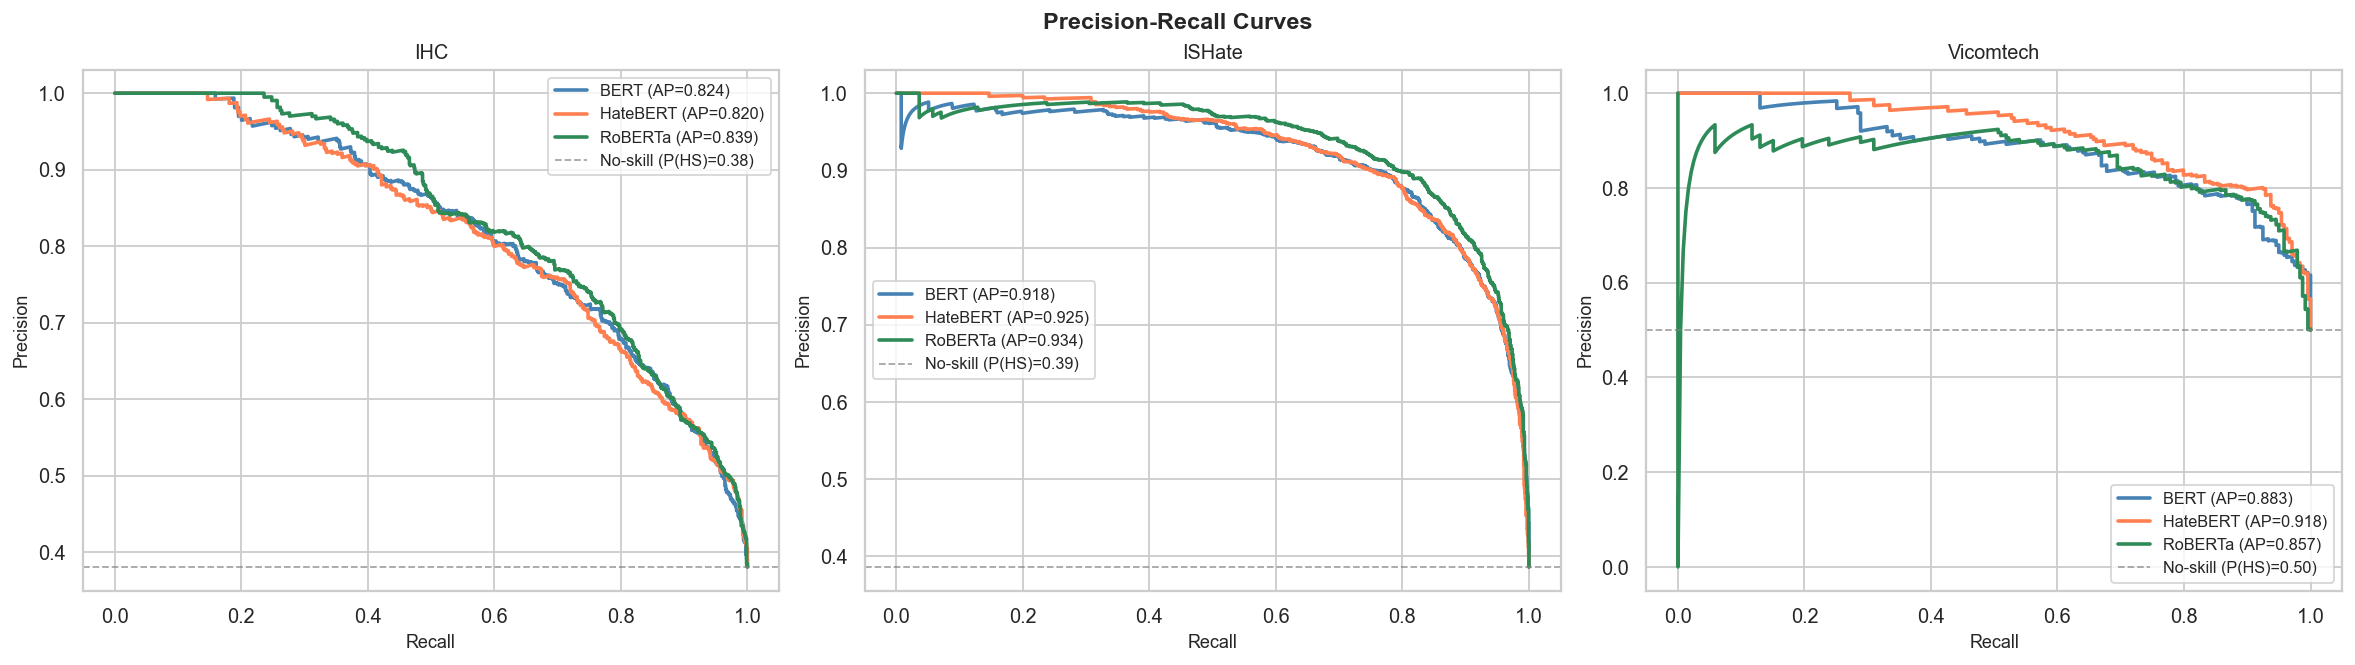

In [110]:
fig, axes = plt.subplots(1, len(DATASETS_CFG), figsize=(6*len(DATASETS_CFG), 5), constrained_layout=True)
fig.suptitle('Precision-Recall Curves', fontsize=13, fontweight='bold')

for ax, dataset_name in zip(axes, list(DATASETS_CFG.keys())):
    for model_name in MODELS:
        r = all_results[(model_name, dataset_name)]
        prec, rec, _ = precision_recall_curve(r['labels'], r['hs_prob'])
        ap = average_precision_score(r['labels'], r['hs_prob'])
        ax.plot(rec, prec, color=MODEL_COLOR[model_name], lw=2,
                label=f"{MODEL_SHORT[model_name]} (AP={ap:.3f})")

    baseline_rate = all_results[(list(MODELS.keys())[0], dataset_name)]['labels'].mean()
    ax.axhline(baseline_rate, color='gray', lw=1, linestyle='--', alpha=0.7,
               label=f'No-skill (P(HS)={baseline_rate:.2f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(dataset_name)
    ax.legend(fontsize=9)

plt.savefig('fig08_pr.png', bbox_inches='tight')
plt.show()

## 8. RAG Handoff Simulation

At each confidence threshold, examples below it would be routed to the RAG retrieval system. The heatmap shows what fraction that is per (model, dataset). The stacked bars show whether the RAG-bound examples are predominantly HS or Non-HS — ideally, the hard/ambiguous examples that RAG was designed for.

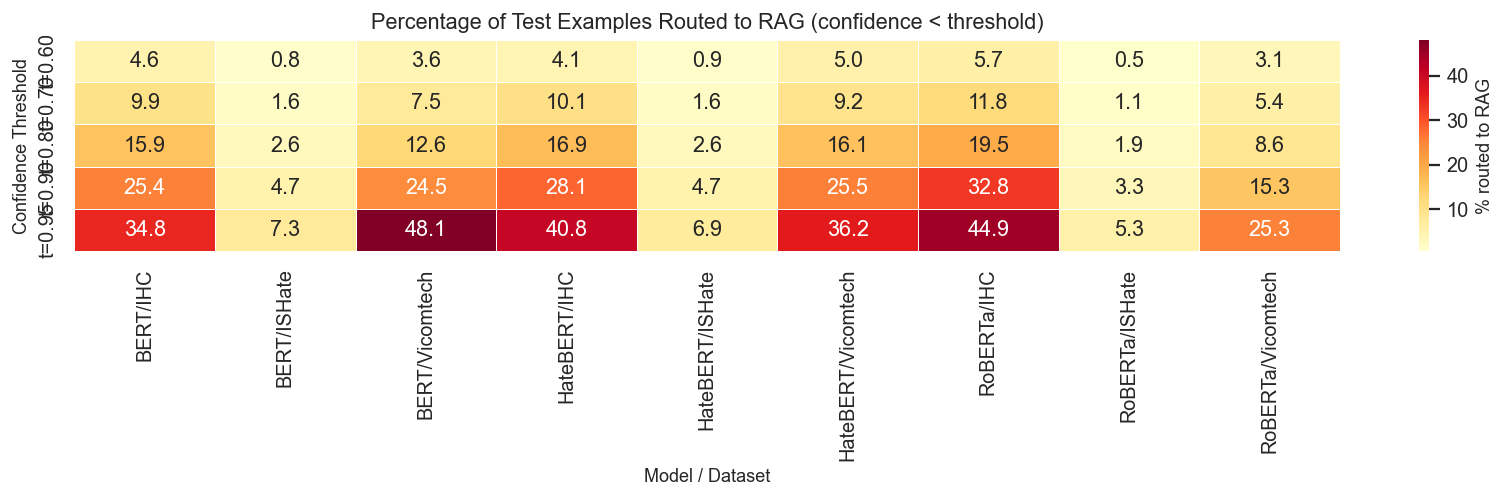


At t=0.90:
  BERT/IHC: 25.4% to RAG
  BERT/ISHate: 4.7% to RAG
  BERT/Vicomtech: 24.5% to RAG
  HateBERT/IHC: 28.1% to RAG
  HateBERT/ISHate: 4.7% to RAG
  HateBERT/Vicomtech: 25.5% to RAG
  RoBERTa/IHC: 32.8% to RAG
  RoBERTa/ISHate: 3.3% to RAG
  RoBERTa/Vicomtech: 15.3% to RAG


In [111]:
cols = [f"{MODEL_SHORT[m]}/{d}" for m in MODELS for d in list(DATASETS_CFG.keys())]
hmap = pd.DataFrame(
    index=[f't={t:.2f}' for t in THRESHOLDS],
    columns=cols,
    dtype=float,
)

for t in THRESHOLDS:
    for model_name in MODELS:
        for dataset_name in list(DATASETS_CFG.keys()):
            r   = all_results[(model_name, dataset_name)]
            pct = (r['confidence'] < t).mean() * 100
            hmap.loc[f't={t:.2f}', f"{MODEL_SHORT[model_name]}/{dataset_name}"] = pct

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    hmap.astype(float), annot=True, fmt='.1f', cmap='YlOrRd',
    ax=ax, cbar_kws={'label': '% routed to RAG'},
    linewidths=0.4,
)
ax.set_title('Percentage of Test Examples Routed to RAG (confidence < threshold)', fontsize=12)
ax.set_xlabel('Model / Dataset')
ax.set_ylabel('Confidence Threshold')
plt.tight_layout()
plt.savefig('fig09_rag_heatmap.png', bbox_inches='tight')
plt.show()

print('\nAt t=0.90:')
for model_name in MODELS:
    for dataset_name in list(DATASETS_CFG.keys()):
        r = all_results[(model_name, dataset_name)]
        pct = (r['confidence'] < 0.90).mean() * 100
        print(f'  {MODEL_SHORT[model_name]}/{dataset_name}: {pct:.1f}% to RAG')

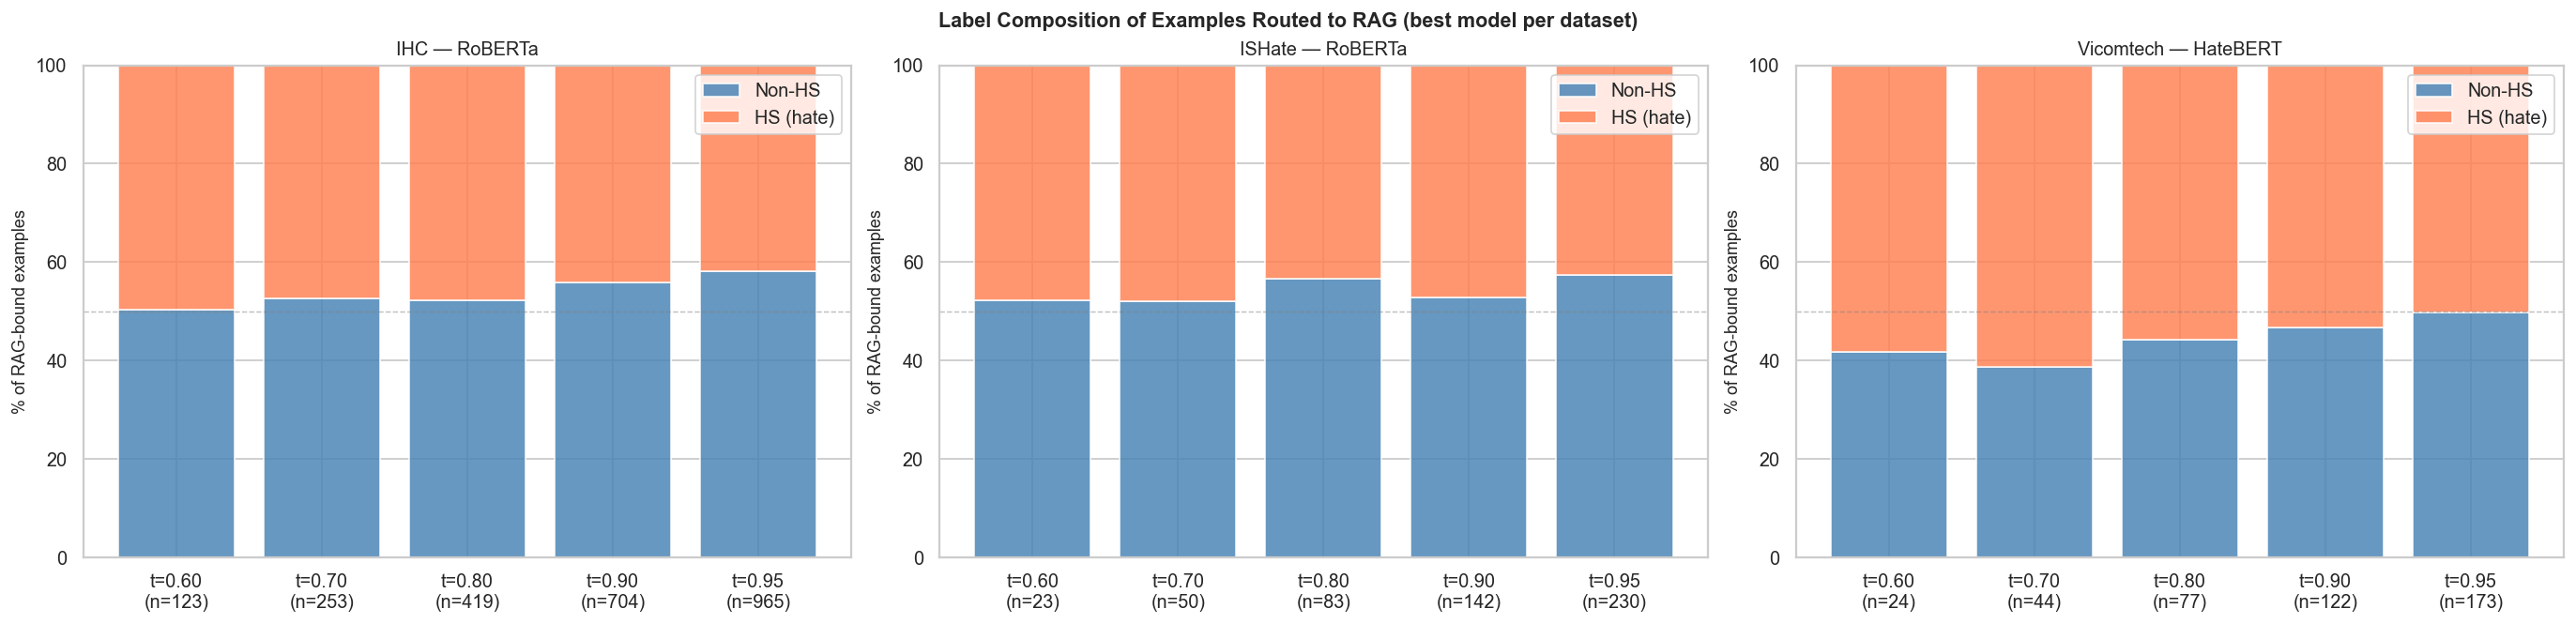

In [112]:
fig, axes = plt.subplots(1, len(DATASETS_CFG), figsize=(7*len(DATASETS_CFG), 5), constrained_layout=True)
fig.suptitle('Label Composition of Examples Routed to RAG (best model per dataset)', fontsize=12, fontweight='bold')

for ax, (dataset_name, best_model) in zip(axes, [(d, best_models[d]) for d in DATASETS_CFG]):
    r = all_results[(best_model, dataset_name)]
    hs_shares, non_hs_shares, totals = [], [], []
    for t in THRESHOLDS:
        mask = r['confidence'] < t
        n = mask.sum()
        totals.append(n)
        if n == 0:
            hs_shares.append(0); non_hs_shares.append(0)
        else:
            hs_shares.append((r['labels'][mask] == 1).mean() * 100)
            non_hs_shares.append((r['labels'][mask] == 0).mean() * 100)

    x = np.arange(len(THRESHOLDS))
    ax.bar(x, non_hs_shares, label='Non-HS', color='steelblue', alpha=0.82)
    ax.bar(x, hs_shares, bottom=non_hs_shares, label='HS (hate)', color='coral', alpha=0.82)
    ax.set_xticks(x)
    ax.set_xticklabels([f't={t:.2f}\n(n={tot:,})' for t, tot in zip(THRESHOLDS, totals)])
    ax.set_ylabel('% of RAG-bound examples')
    ax.set_ylim(0, 100)
    ax.set_title(f'{dataset_name} — {MODEL_SHORT[best_model]}')
    ax.legend()
    ax.axhline(50, color='gray', lw=0.8, linestyle='--', alpha=0.5)

plt.savefig('fig10_rag_composition.png', bbox_inches='tight')
plt.show()

## 9. IHC — Implicit vs. Explicit Hate Breakdown

IHC preserves the original three-class label (`not_hate`, `explicit_hate`, `implicit_hate`). **Implicit hate** uses coded language, dog whistles, and euphemisms — no explicit slurs. The key hypothesis: models are *less confident* on implicit hate because there are fewer surface-level cues.

HateBERT was pretrained on hate speech forums (Reddit, Gab) and may be better at recognising implicit patterns.

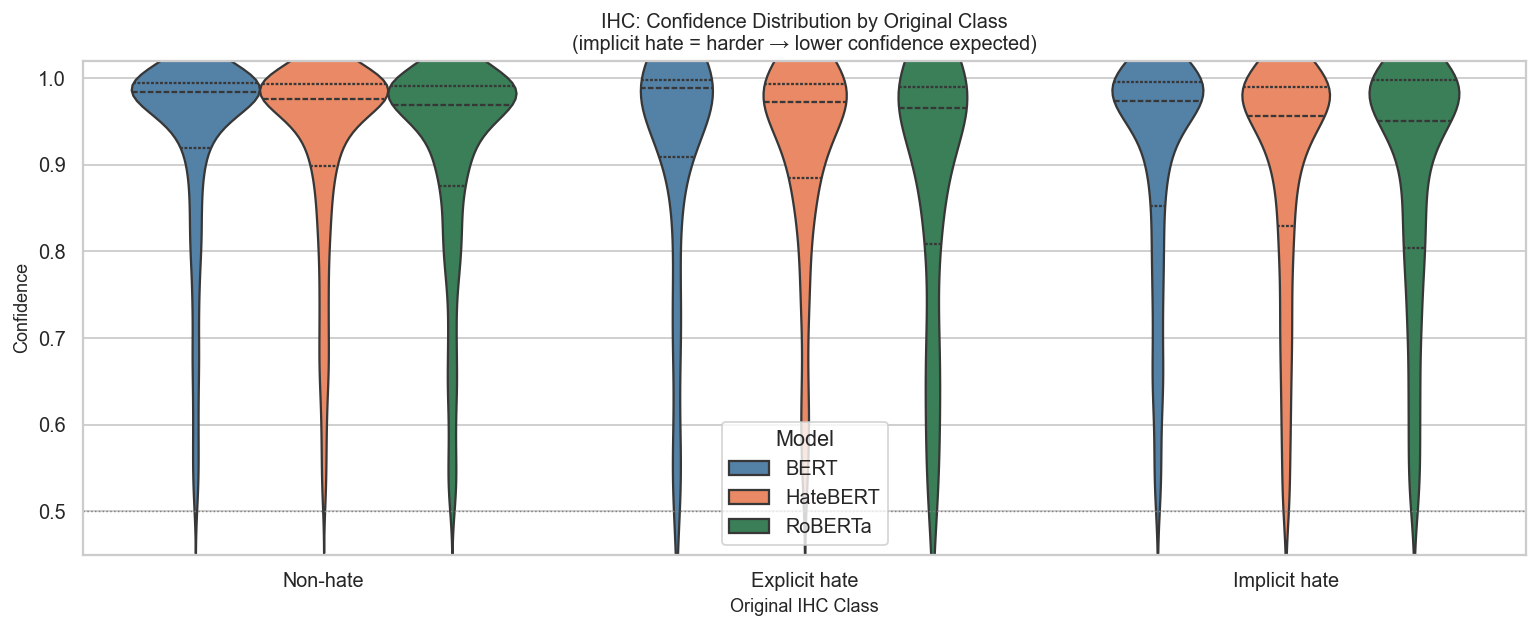

In [113]:
records_cls = []
for model_name in MODELS:
    r = all_results[(model_name, 'IHC')]
    for i in range(len(r['labels'])):
        records_cls.append({
            'Model':      MODEL_SHORT[model_name],
            'orig_class': r['orig_class'][i],
            'confidence': r['confidence'][i],
            'correct':    bool(r['correct'][i]),
        })

df_cls = pd.DataFrame(records_cls)
class_order = ['not_hate', 'explicit_hate', 'implicit_hate']
class_labels = {'not_hate': 'Non-hate', 'explicit_hate': 'Explicit hate', 'implicit_hate': 'Implicit hate'}
df_cls['Class'] = df_cls['orig_class'].map(class_labels)
label_order = [class_labels[c] for c in class_order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(
    data=df_cls, x='Class', y='confidence', hue='Model',
    order=label_order,
    palette={MODEL_SHORT[m]: MODEL_COLOR[m] for m in MODELS},
    inner='quartile', ax=ax,
)
ax.set_ylim(0.45, 1.02)
ax.set_title('IHC: Confidence Distribution by Original Class\n(implicit hate = harder → lower confidence expected)')
ax.set_xlabel('Original IHC Class')
ax.set_ylabel('Confidence')
ax.axhline(0.5, color='gray', lw=0.8, linestyle=':')
plt.tight_layout()
plt.savefig('fig11_ihc_class_violin.png', bbox_inches='tight')
plt.show()

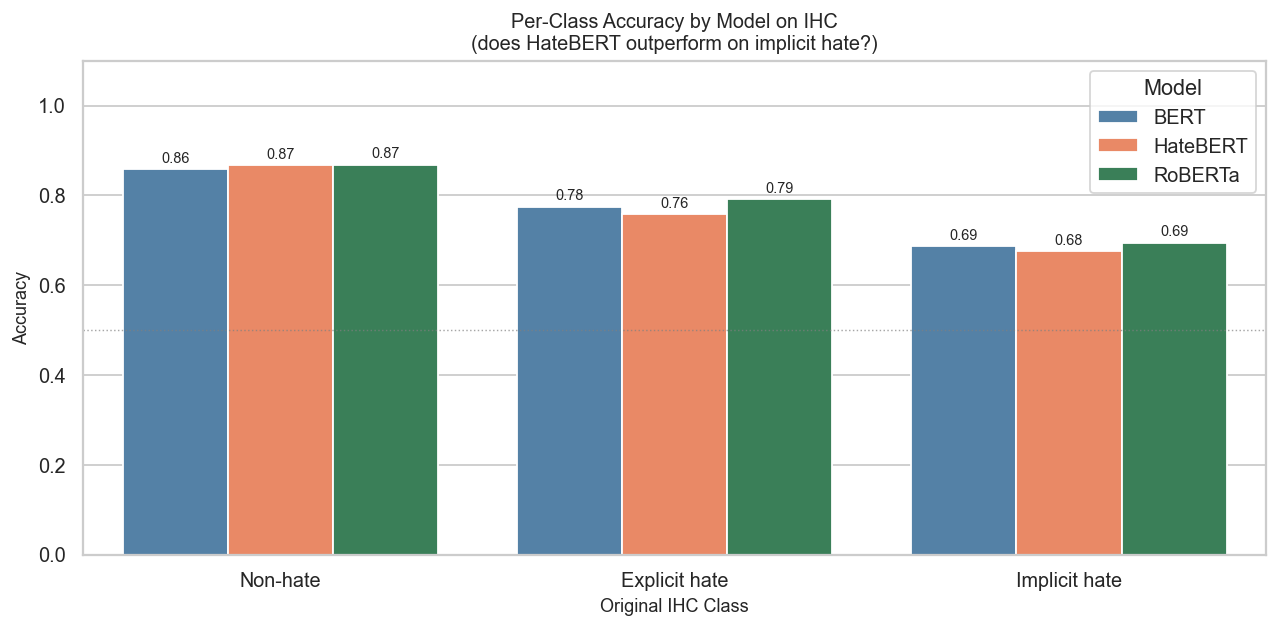

In [114]:
acc_records = []
for model_name in MODELS:
    r = all_results[(model_name, 'IHC')]
    for orig_cls in class_order:
        mask = r['orig_class'] == orig_cls
        if mask.sum() == 0:
            continue
        acc_records.append({
            'Model':      MODEL_SHORT[model_name],
            'Class':      class_labels[orig_cls],
            'Accuracy':   r['correct'][mask].mean(),
            'n':          int(mask.sum()),
        })

df_acc = pd.DataFrame(acc_records)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=df_acc, x='Class', y='Accuracy', hue='Model',
    order=label_order,
    palette={MODEL_SHORT[m]: MODEL_COLOR[m] for m in MODELS},
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt='{:.2f}', fontsize=8, padding=2)
ax.set_title('Per-Class Accuracy by Model on IHC\n(does HateBERT outperform on implicit hate?)')
ax.set_xlabel('Original IHC Class')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', lw=0.8, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('fig12_ihc_class_accuracy.png', bbox_inches='tight')
plt.show()

## 10. Curated Example Categories

The following eight categories are programmatically selected from the test sets and illustrate different regimes of the confidence-threshold mechanism. All examples use the best-performing model on each dataset.

| # | Category | What it shows |
|---|----------|---------------|
| 1 | High-conf correct HS | Prototypical, unambiguous hate speech |
| 2 | High-conf wrong (FN) | Dangerous: HS missed confidently — *these would not go to RAG* |
| 3 | High-conf wrong (FP) | Over-trigger: benign text flagged confidently |
| 4 | Low-conf boundary | Ideal RAG candidates — model is genuinely unsure |
| 5 | Consensus failures | All 3 models wrong — systematic bias, not model-specific |
| 6 | IHC implicit hate missed | Subtle HS the model cannot detect |
| 7 | Short-text confident failures | Short texts lack context — ISHate |
| 8 | Uncertain but correct | Correct prediction, low confidence — borderline cases |

Columns: `text` (110 chars), `true_label`, `pred_label`, `confidence`, `orig_class` (IHC only).

In [115]:
print(f'Best model for IHC:    {MODEL_SHORT[best_ihc]}')
print(f'Best model for ISHate: {MODEL_SHORT[best_ishate]}')

Best model for IHC:    RoBERTa
Best model for ISHate: RoBERTa


In [116]:
# Category 1 — Prototypical HS: high confidence, correct, label=HS
for dataset_name, best_model in [(d, best_models[d]) for d in DATASETS_CFG]:
    r    = all_results[(best_model, dataset_name)]
    mask = r['correct'] & (r['labels'] == 1) & (r['confidence'] > 0.95)
    print(f'\n--- Category 1: Prototypical HS — {dataset_name} ({MODEL_SHORT[best_model]}) ---')
    print(f'Found {mask.sum()} examples with conf > 0.95, correct, HS')
    display(
        get_examples_df((best_model, dataset_name), mask, sort_col='confidence', ascending=False)
        .style.format({'confidence': '{:.3f}'}).set_caption(
            f'Category 1 — Prototypical HS | {dataset_name} | {MODEL_SHORT[best_model]}')
    )


--- Category 1: Prototypical HS — IHC (RoBERTa) ---
Found 350 examples with conf > 0.95, correct, HS


,text,true_label,pred_label,confidence,orig_class
0,"bravo.. you have to stop them at all cost, the muslim and the globalist.",HS,HS,1.000,implicit_hate
1,"no might, no maybe, just do itdeport all illegals all criminals",HS,HS,1.000,implicit_hate
2,You know the only good thing about being a Jewish chimney sweeper in Auschwitz? You get to have all your famil,HS,HS,1.000,implicit_hate
3,too many cooks spoil the soup!. too many rino's spoil the party's agenda. i'd like 2 bend em over & let a real,HS,HS,1.000,implicit_hate
4,"A gay guy, A black guy, and A Jew get hit by a bus They all appear in front of the gates of heaven. The Angel",HS,HS,1.000,implicit_hate
5,make it so horrendous that illegals don't want to come back illegally.,HS,HS,1.000,implicit_hate
6,"Also, I can't imagine anything more counterproductive than getting into fights with shit-tier niggers and othe",HS,HS,1.000,explicit_hate
7,he brought them here to have his own enemy combatant army to inflict islam on us. round them up. send them bac,HS,HS,1.000,implicit_hate



--- Category 1: Prototypical HS — ISHate (RoBERTa) ---
Found 1409 examples with conf > 0.95, correct, HS


,text,true_label,pred_label,confidence
0,in order for jews to triumph all it takes is for white men to do nothing .,HS,HS,1.000
1,from china to india to egypt to meso america all ancient white civilizations were destroyed by diversity .,HS,HS,1.000
2,"what is a "" racist "" "" ? what is a "" "" hate group "" "" ? these are euphemisms created to prevent white self-d",HS,HS,1.000
3,as it should be . all that is happening to europe today hitler foresaw . he also knew the jewish plan to dest,HS,HS,1.000
4,"more anti-white hate propaganda re : wwii - it's not just the germans all whites guilty for fake "" holocaus",HS,HS,1.000
5,white self-hate : master stroke of the george lincoln rockwell #whitepeople #whitepride #wpww,HS,HS,1.000
6,"it's a hollow simulacrum of "" white advocacy "" "" if jews are accepted as white """,HS,HS,1.000
7,: whores of babylon : lena dunham celebrates white genocide via #whitegenocide #waronwhites,HS,HS,1.000



--- Category 1: Prototypical HS — Vicomtech (HateBERT) ---
Found 143 examples with conf > 0.95, correct, HS


,text,true_label,pred_label,confidence
0,In the eyes of the Jew and the libtard there is a race problem and the problem is us !,HS,HS,0.992
1,Then we can all live in a global utopia with the Jew running the show - cant wait Nothing short of a brain tra,HS,HS,0.992
2,"Why do n't White Europeans and Americans grow a set of balls , and deport these Black and brown animals from t",HS,HS,0.992
3,"oddly i would find it worst if she here black , since Negroes are the most inferior and scum bag humanoid race",HS,HS,0.992
4,"Well, at least these dumb negroes got the fact that Jews are evil right ; though I suspect whitey and the jews",HS,HS,0.992
5,I've often pointed out that negroes are more stupid than I can even imagine if they actually think they 're go,HS,HS,0.991
6,"The kikes probably put the Leftist up to it , to make it seem like they do n't have total control of everyone",HS,HS,0.991
7,If Canada was small the nonwhites would be everywhere but so many whites live rurally or in small towns so the,HS,HS,0.991


In [117]:
# Category 2 — Dangerous FN: model is confident Non-HS but true label is HS
# These would NOT be routed to RAG even though they are wrong
for dataset_name, best_model in [(d, best_models[d]) for d in DATASETS_CFG]:
    r    = all_results[(best_model, dataset_name)]
    mask = (~r['correct']) & (r['labels'] == 1) & (r['predicted'] == 0) & (r['confidence'] > 0.85)
    print(f'\n--- Category 2: Dangerous FN (high-conf missed HS) — {dataset_name} ({MODEL_SHORT[best_model]}) ---')
    print(f'Found {mask.sum()} examples — missed HS with confidence > 0.85 (would NOT go to RAG)')
    if mask.sum() > 0:
        display(
            get_examples_df((best_model, dataset_name), mask, sort_col='confidence', ascending=False)
            .style.format({'confidence': '{:.3f}'}).set_caption(
                f'Category 2 — Dangerous FN | {dataset_name} | {MODEL_SHORT[best_model]}')
        )


--- Category 2: Dangerous FN (high-conf missed HS) — IHC (RoBERTa) ---
Found 136 examples — missed HS with confidence > 0.85 (would NOT go to RAG)


,text,true_label,pred_label,confidence,orig_class
0,: hi it's me the soviet apologist here to talk to you about human rights .,HS,Non-HS,0.997,implicit_hate
1,#democrat senator byrd was a exalted cyclops of the #kkk .,HS,Non-HS,0.994,implicit_hate
2,why is indian media silent on the risk that & his minister's conduct has posed to lakhs of indians in uganda ?,HS,Non-HS,0.994,implicit_hate
3,time will prove who r allies . national socialist party has much bigger canvass spreading far & wide .,HS,Non-HS,0.993,implicit_hate
4,via : minnesota : three muslims convicted of conspiring to join the islamic state #tcot,HS,Non-HS,0.993,implicit_hate
5,okay so you're the ethnonationalist spencer and he's the racist spencer ?,HS,Non-HS,0.993,implicit_hate
6,- 1 fertile white womb,HS,Non-HS,0.992,implicit_hate
7,conservatives have no moral compass they just follow the cultural marxists 10 paces behind in ' righteo,HS,Non-HS,0.992,implicit_hate



--- Category 2: Dangerous FN (high-conf missed HS) — ISHate (RoBERTa) ---
Found 205 examples — missed HS with confidence > 0.85 (would NOT go to RAG)


,text,true_label,pred_label,confidence
0,"Here I share pic about Men over women, dominant relationships http://t.co/v5gjFpJ8zH",HS,Non-HS,0.999
1,Many of them are doing just as their masters desire .,HS,Non-HS,0.999
2,"Thank you for your kind words , hope to meet you in the new white world one day soon .",HS,Non-HS,0.999
3,"Good luck with your bugchasing , homo . . .",HS,Non-HS,0.999
4,He got what he deserved .,HS,Non-HS,0.999
5,Bbut they are creeping in slowly seeing more and more these days .,HS,Non-HS,0.999
6,A good old bit of nostalgia from the days when there was hardly a blade of grass or a coon on the pitch .,HS,Non-HS,0.999
7,A few weeks ago i started looking into doing that and have got a few pictures and LOADS of mobile numbers so f,HS,Non-HS,0.999



--- Category 2: Dangerous FN (high-conf missed HS) — Vicomtech (HateBERT) ---
Found 15 examples — missed HS with confidence > 0.85 (would NOT go to RAG)


,text,true_label,pred_label,confidence
0,"Deanna Spingola and Dr. Lorraine Day - Zionism , the Holocaust , Aids and Vaccines YouTube - Deanna Spingola a",HS,Non-HS,0.989
1,"Oh yeah , no mugshot picture on the page of course , you have to watch the video report to find out it was yet",HS,Non-HS,0.981
2,Back to where ya came from !,HS,Non-HS,0.979
3,Most of these videos belong on the Animal Planet tv channel .,HS,Non-HS,0.978
4,"Although many have asked us to put it aside in politics , this thread is for all those who see where HATE FITS",HS,Non-HS,0.976
5,Hell to have a teacher like this .,HS,Non-HS,0.973
6,"Good luck with your bugchasing , homo . . .",HS,Non-HS,0.971
7,He got what he deserved .,HS,Non-HS,0.958


In [118]:
# Category 3 — Overconfident FP: model flags as HS with high confidence but text is Non-HS
# Typical causes: counterspeech, news reporting, sarcasm, or in-group language
for dataset_name, best_model in [(d, best_models[d]) for d in DATASETS_CFG]:
    r    = all_results[(best_model, dataset_name)]
    mask = (~r['correct']) & (r['labels'] == 0) & (r['predicted'] == 1) & (r['confidence'] > 0.85)
    print(f'\n--- Category 3: Overconfident FP (benign text flagged as HS) — {dataset_name} ({MODEL_SHORT[best_model]}) ---')
    print(f'Found {mask.sum()} examples — Non-HS flagged with confidence > 0.85')
    if mask.sum() > 0:
        display(
            get_examples_df((best_model, dataset_name), mask, sort_col='confidence', ascending=False)
            .style.format({'confidence': '{:.3f}'}).set_caption(
                f'Category 3 — Overconfident FP | {dataset_name} | {MODEL_SHORT[best_model]}')
        )


--- Category 3: Overconfident FP (benign text flagged as HS) — IHC (RoBERTa) ---
Found 80 examples — Non-HS flagged with confidence > 0.85


,text,true_label,pred_label,confidence,orig_class
0,great idea . let's get this wall built . way to go . #buildthewall,Non-HS,HS,0.999,not_hate
1,racist old white guys are in for a huge surprise in november .,Non-HS,HS,0.996,not_hate
2,illegal aliens should be suing in a mexican court with a mexican attorney in mexico . they have no rights in,Non-HS,HS,0.994,not_hate
3,the growing anti-white agenda ; obamas overt cleansing of white america ; rebel flag desecrated | american fre,Non-HS,HS,0.994,not_hate
4,our great white race is coming back 2 life and does not like what we all see in america . sieg heil ! #working,Non-HS,HS,0.992,not_hate
5,refugees need to have there homeland made safe they can go home and build a new america there . starting with,Non-HS,HS,0.991,not_hate
6,: white genocide accelerates in england : white british pupils will be outnumbered by 2037,Non-HS,HS,0.989,not_hate
7,have you ever been such a degenerate that your only accomplishment is being white,Non-HS,HS,0.983,not_hate



--- Category 3: Overconfident FP (benign text flagged as HS) — ISHate (RoBERTa) ---
Found 220 examples — Non-HS flagged with confidence > 0.85


,text,true_label,pred_label,confidence
0,hypnotize synthesize love is a lie like a hole in the sky then you die,Non-HS,HS,1.000
1,sharia Law Tessa is that not tony Blair's wife no y do you let islam law into the country stupid woman with,Non-HS,HS,1.000
2,but we muslims know the truth that the jews wish to be killed him but they didn't ..,Non-HS,HS,1.000
3,“get premium you cheap skank”,Non-HS,HS,1.000
4,"you are wrong , in islamic countries they leave their shops open and go to prayer and come back to find it un",Non-HS,HS,1.000
5,the younger limerick crowd say the gangs from moyross are in regular fights with the poles they go around in t,Non-HS,HS,1.000
6,"mm , you are full of confidence , but why is the lowest rate of crimes are in the islamic countries ?",Non-HS,HS,1.000
7,if the sensi knows what they are doing they will break down the kata and show you how each move or movies appl,Non-HS,HS,1.000



--- Category 3: Overconfident FP (benign text flagged as HS) — Vicomtech (HateBERT) ---
Found 25 examples — Non-HS flagged with confidence > 0.85


,text,true_label,pred_label,confidence
0,"That type of negroes call your kind of brothas , Uncle Tom .",Non-HS,HS,0.985
1,They have properly learnt their Zionist lesson ...,Non-HS,HS,0.983
2,When the homos tried to have a fag pride parade in Serbia a few years ago they were beaten up .,Non-HS,HS,0.980
3,"Of course the county is lovely , in facts its gods country in our book BUT the cities are rat infested with en",Non-HS,HS,0.976
4,These people who want foreign aid increased are the same people who walk past irish people living rough on the,Non-HS,HS,0.973
5,More than that I cringe every time I go to hang out with my friends and they blast this filth in their cars an,Non-HS,HS,0.969
6,"More likely they 're afraid of having to marry and deal with a snotty GI-Jane-dyke , only to be dragged into c",Non-HS,HS,0.964
7,What did those poor monkeys ever do to you ?,Non-HS,HS,0.964


In [119]:
# Category 4 — Ideal RAG candidates: confidence very close to the decision boundary
# The model is genuinely unsure — exactly the examples a RAG system is designed to handle
for dataset_name, best_model in [(d, best_models[d]) for d in DATASETS_CFG]:
    r    = all_results[(best_model, dataset_name)]
    mask = r['confidence'] < 0.65
    print(f'\n--- Category 4: Ideal RAG Candidates (conf < 0.65) — {dataset_name} ({MODEL_SHORT[best_model]}) ---')
    print(f'Found {mask.sum()} examples ({mask.mean()*100:.1f}% of test set)')
    n_correct = r['correct'][mask].sum()
    print(f'  Of these: {n_correct} correct ({n_correct/max(mask.sum(),1)*100:.1f}%), {mask.sum()-n_correct} incorrect')
    display(
        get_examples_df((best_model, dataset_name), mask, sort_col='confidence', ascending=True)
        .style.format({'confidence': '{:.3f}'}).set_caption(
            f'Category 4 — Lowest Confidence (Ideal RAG Candidates) | {dataset_name}')
    )


--- Category 4: Ideal RAG Candidates (conf < 0.65) — IHC (RoBERTa) ---
Found 187 examples (8.7% of test set)
  Of these: 104 correct (55.6%), 83 incorrect


,text,true_label,pred_label,confidence,orig_class
0,pro-white rallies organized across the globe for march via,Non-HS,HS,0.500,not_hate
1,lmao ... it's always the jews who stage these so called hate crimes ...,HS,Non-HS,0.501,implicit_hate
2,what say you ? ? on point about so much but ... demographics ? white identity ? aj keeps on shilling for jews,HS,HS,0.502,implicit_hate
3,i oppose it for heathy white babies . in that instance a white ethno-state would have a clear interest in see,HS,Non-HS,0.502,implicit_hate
4,a key clue to the cred of any rightist group is whether they go after cucks like ryan mccain graham . if not,HS,HS,0.502,explicit_hate
5,alt right / nationalists are ok with muslims ? surprising,Non-HS,Non-HS,0.503,not_hate
6,: ku klux klan heads to ferguson race riots to guard white businesses and protect innocent whites,HS,Non-HS,0.504,implicit_hate
7,the statistics didnt say that . but the people perceives more violence due above all to the african migrants,HS,Non-HS,0.505,implicit_hate



--- Category 4: Ideal RAG Candidates (conf < 0.65) — ISHate (RoBERTa) ---
Found 37 examples (0.8% of test set)
  Of these: 20 correct (54.1%), 17 incorrect


,text,true_label,pred_label,confidence
0,"I feel so sorry for all you people living there , wish you could all move here hopefully you do n't suffer lik",HS,HS,0.502
1,Black and Asian immigrants who are coming in and those who were borne here and their breading patterns are the,HS,Non-HS,0.505
2,Stop the spread of #misandry. Fight for men's rights today! #OWS #tcot #tlot #AskTheHEEL #WomenAgainstFeminism,Non-HS,Non-HS,0.505
3,@John_KissMyBot @Lisa23503910 @realDonaldTrump Expose the Corruption #DeclassifyFISA #MAGA #AmericaFirst #KAG,Non-HS,Non-HS,0.519
4,This attack on a young boy should be condemned by all who post on this site . it does n't matter if the lad is,Non-HS,Non-HS,0.523
5,"in that is killing the innocent Palestinian,specially the children?wow!great country isn't it?lol..",HS,Non-HS,0.524
6,@simplecotton11 RT @realDonaldTrump Please arrest/prosecute all Governors & Mayors who are violating any Feder,Non-HS,HS,0.525
7,@charliekirk11 @Bimbys #EnemyCombatants should be used by @TheJusticeDept to stop them from aiding and abettin,HS,Non-HS,0.540



--- Category 4: Ideal RAG Candidates (conf < 0.65) — Vicomtech (HateBERT) ---
Found 35 examples (7.3% of test set)
  Of these: 17 correct (48.6%), 18 incorrect


,text,true_label,pred_label,confidence
0,The above poster is correct when we stop supporting then they 're in terrible danger .,Non-HS,Non-HS,0.504
1,I was trying to find out if the Egyptians were white or not and my search brought me to a thread on this site,Non-HS,HS,0.509
2,A pile of burned offerings .,Non-HS,Non-HS,0.509
3,"i do this and the looks i get out of disgust are regular but i happily carry on walking and laugh them off , t",Non-HS,HS,0.529
4,"Hi Im tv free do n't have kids yet reading mending , sewing , menting board games radio study extra curricula",HS,Non-HS,0.529
5,what about it. that 's exactly what I said and I meant every word he thought I might and that was enough and w,HS,HS,0.530
6,Teach our men to be men again and defend our countries and women folk against the non white .,HS,HS,0.535
7,And the sad thing is the white students at those schools will act like that too .,HS,Non-HS,0.538


In [120]:
# Category 5 — Consensus failures: ALL 3 models predict incorrectly
# These represent systematic bias or genuinely ambiguous/mislabelled examples
for dataset_name in list(DATASETS_CFG.keys()):
    model_list  = list(MODELS.keys())
    r0          = all_results[(model_list[0], dataset_name)]
    all_wrong   = ~r0['correct']
    avg_conf    = r0['confidence'].copy()
    for mn in model_list[1:]:
        r = all_results[(mn, dataset_name)]
        all_wrong = all_wrong & ~r['correct']
        avg_conf  = avg_conf + r['confidence']
    avg_conf /= len(model_list)

    n_consensus = all_wrong.sum()
    print(f'\n--- Category 5: Consensus Failures (all 3 wrong) — {dataset_name} ---')
    print(f'Found {n_consensus} examples ({n_consensus/len(r0["labels"])*100:.1f}% of test set)')

    preds_all = {MODEL_SHORT[mn]: all_results[(mn, dataset_name)]['predicted'] for mn in model_list}
    df_cons = pd.DataFrame({
        'text':      r0['texts'][all_wrong],
        'true':      r0['labels'][all_wrong],
        'BERT':      preds_all['BERT'][all_wrong],
        'HateBERT':  preds_all['HateBERT'][all_wrong],
        'RoBERTa':   preds_all['RoBERTa'][all_wrong],
        'avg_conf':  avg_conf[all_wrong],
    })
    label_map = {0: 'Non-HS', 1: 'HS'}
    for col in ['true', 'BERT', 'HateBERT', 'RoBERTa']:
        df_cons[col] = df_cons[col].map(label_map)
    if r0['orig_class'] is not None:
        df_cons['orig_class'] = r0['orig_class'][all_wrong]
    df_cons['text'] = df_cons['text'].str[:110]
    df_cons = df_cons.sort_values('avg_conf', ascending=False).head(8).reset_index(drop=True)

    cols = ['text', 'true', 'BERT', 'HateBERT', 'RoBERTa', 'avg_conf']
    if 'orig_class' in df_cons.columns:
        cols.append('orig_class')
    display(df_cons[cols].style.format({'avg_conf': '{:.3f}'}).set_caption(
        f'Category 5 — Consensus Failures | {dataset_name}'))


--- Category 5: Consensus Failures (all 3 wrong) — IHC ---
Found 243 examples (11.3% of test set)


,text,true,BERT,HateBERT,RoBERTa,avg_conf,orig_class
0,time will prove who r allies . national socialist party has much bigger canvass spreading far & wide .,HS,Non-HS,Non-HS,Non-HS,0.996,implicit_hate
1,illegal aliens should be suing in a mexican court with a mexican attorney in mexico . they have no rights in,Non-HS,HS,HS,HS,0.995,not_hate
2,via : minnesota : three muslims convicted of conspiring to join the islamic state #tcot,HS,Non-HS,Non-HS,Non-HS,0.994,implicit_hate
3,#democrat senator byrd was a exalted cyclops of the #kkk .,HS,Non-HS,Non-HS,Non-HS,0.993,implicit_hate
4,the growing anti-white agenda ; obamas overt cleansing of white america ; rebel flag desecrated | american fre,Non-HS,HS,HS,HS,0.992,not_hate
5,why is indian media silent on the risk that & his minister's conduct has posed to lakhs of indians in uganda ?,HS,Non-HS,Non-HS,Non-HS,0.992,implicit_hate
6,action report : america first banner drop on tuesday december 5 identity evropa activists dropped a massive,HS,Non-HS,Non-HS,Non-HS,0.991,implicit_hate
7,"good question ! once again - "" small number of individuals "" "" phoenix antifa used tear gas - boston bottl",HS,Non-HS,Non-HS,Non-HS,0.991,implicit_hate



--- Category 5: Consensus Failures (all 3 wrong) — ISHate ---
Found 219 examples (5.0% of test set)


,text,true,BERT,HateBERT,RoBERTa,avg_conf
0,new to this site looking for pure females in or around princeton ky THE ONLY WAY TO SURVIVE IS TO GO FORTH AND,Non-HS,HS,HS,HS,1.000
1,but we muslims know the truth that the jews wish to be killed him but they didn't ..,Non-HS,HS,HS,HS,1.000
2,"Stop making Muslims' life like hell in their own land, then they would not need to migrate anywhere.",Non-HS,HS,HS,HS,1.000
3,why what have muslim's done to u?,Non-HS,HS,HS,HS,1.000
4,sharia Law Tessa is that not tony Blair's wife no y do you let islam law into the country stupid woman with,Non-HS,HS,HS,HS,1.000
5,The jews media will never report on this incident or any kind of incident like this ever.Wake up White people,Non-HS,HS,HS,HS,0.999
6,Girls bitch about how immature guys are and then they do shot like That #WomenSuck,Non-HS,HS,HS,HS,0.999
7,"Yes, Philidelphia has been over run with black savages , left and right .",Non-HS,HS,HS,HS,0.999



--- Category 5: Consensus Failures (all 3 wrong) — Vicomtech ---
Found 47 examples (9.8% of test set)


,text,true,BERT,HateBERT,RoBERTa,avg_conf
0,Most of these videos belong on the Animal Planet tv channel .,HS,Non-HS,Non-HS,Non-HS,0.982
1,"Oh yeah , no mugshot picture on the page of course , you have to watch the video report to find out it was yet",HS,Non-HS,Non-HS,Non-HS,0.982
2,Back to where ya came from !,HS,Non-HS,Non-HS,Non-HS,0.981
3,"Deanna Spingola and Dr. Lorraine Day - Zionism , the Holocaust , Aids and Vaccines YouTube - Deanna Spingola a",HS,Non-HS,Non-HS,Non-HS,0.976
4,He got what he deserved .,HS,Non-HS,Non-HS,Non-HS,0.974
5,"That type of negroes call your kind of brothas , Uncle Tom .",Non-HS,HS,HS,HS,0.974
6,When the homos tried to have a fag pride parade in Serbia a few years ago they were beaten up .,Non-HS,HS,HS,HS,0.971
7,"Of course the county is lovely , in facts its gods country in our book BUT the cities are rat infested with en",Non-HS,HS,HS,HS,0.969


In [121]:
# Category 6 — IHC implicit hate missed (false negatives on implicit_hate class only)
# Confirms that implicit hate is harder: the model predicts Non-HS for subtle hate
r    = all_results[(best_ihc, 'IHC')]
mask = (r['orig_class'] == 'implicit_hate') & (r['predicted'] == 0)
print(f'--- Category 6: IHC Implicit Hate Missed — {MODEL_SHORT[best_ihc]} ---')
print(f'Found {mask.sum()} implicit_hate examples predicted as Non-HS')
print(f'(out of {(r["orig_class"] == "implicit_hate").sum()} total implicit_hate in test set)')
display(
    get_examples_df((best_ihc, 'IHC'), mask, sort_col='confidence', ascending=False)
    .style.format({'confidence': '{:.3f}'}).set_caption(
        f'Category 6 — IHC Implicit Hate Missed | {MODEL_SHORT[best_ihc]}')
)

--- Category 6: IHC Implicit Hate Missed — RoBERTa ---
Found 213 implicit_hate examples predicted as Non-HS
(out of 698 total implicit_hate in test set)


,text,true_label,pred_label,confidence,orig_class
0,: hi it's me the soviet apologist here to talk to you about human rights .,HS,Non-HS,0.997,implicit_hate
1,#democrat senator byrd was a exalted cyclops of the #kkk .,HS,Non-HS,0.994,implicit_hate
2,why is indian media silent on the risk that & his minister's conduct has posed to lakhs of indians in uganda ?,HS,Non-HS,0.994,implicit_hate
3,time will prove who r allies . national socialist party has much bigger canvass spreading far & wide .,HS,Non-HS,0.993,implicit_hate
4,via : minnesota : three muslims convicted of conspiring to join the islamic state #tcot,HS,Non-HS,0.993,implicit_hate
5,okay so you're the ethnonationalist spencer and he's the racist spencer ?,HS,Non-HS,0.993,implicit_hate
6,- 1 fertile white womb,HS,Non-HS,0.992,implicit_hate
7,conservatives have no moral compass they just follow the cultural marxists 10 paces behind in ' righteo,HS,Non-HS,0.992,implicit_hate


In [122]:
# Category 7 — Short-text confident failures (ISHate focus)
# Short posts lack context; if the model is confidently wrong, it has over-relied on surface cues
r         = all_results[(best_ishate, 'ISHate')]
word_lens = np.array([len(t.split()) for t in r['texts']])
mask      = (~r['correct']) & (r['confidence'] > 0.85) & (word_lens < 12)
print(f'--- Category 7: Short-text Confident Failures — ISHate ({MODEL_SHORT[best_ishate]}) ---')
print(f'Found {mask.sum()} incorrect examples with confidence > 0.85 and < 12 words')
if mask.sum() > 0:
    df_short = get_examples_df((best_ishate, 'ISHate'), mask, sort_col='confidence', ascending=False)
    df_short.insert(1, 'words', word_lens[mask][np.argsort(-r['confidence'][mask])][:8])
    display(df_short.style.format({'confidence': '{:.3f}'}).set_caption(
        f'Category 7 — Short-text Confident Failures | ISHate'))

--- Category 7: Short-text Confident Failures — ISHate (RoBERTa) ---
Found 75 incorrect examples with confidence > 0.85 and < 12 words


,text,words,true_label,pred_label,confidence
0,“get premium you cheap skank”,5,Non-HS,HS,1.000
1,"1. morbidly melancholy , 2. irritable ; bad-tempered ; splenetic .",11,Non-HS,HS,1.000
2,QUIT JUDGING THE MUSLIMS!!!!!!!!!,4,Non-HS,HS,1.000
3,why what have muslim's done to u?,7,Non-HS,HS,1.000
4,STFU about Islam and abuse of women.,7,Non-HS,HS,1.000
5,KILL YOUR SELF IMMEDIATLY!!!!,4,Non-HS,HS,1.000
6,intelligent whites doesnt hate other religion!,6,Non-HS,HS,1.000
7,what u whities are doing to this world is sick,10,Non-HS,HS,1.000


In [123]:
# Category 8 — Uncertain but correct: low confidence, right answer
# These show genuine ambiguity: the model's uncertainty is warranted even when it guesses correctly
# Argument for routing even correct low-conf predictions to RAG for verification
for dataset_name, best_model in [(d, best_models[d]) for d in DATASETS_CFG]:
    r    = all_results[(best_model, dataset_name)]
    mask = r['correct'] & (r['confidence'] < 0.65)
    print(f'\n--- Category 8: Uncertain but Correct (conf < 0.65) — {dataset_name} ({MODEL_SHORT[best_model]}) ---')
    print(f'Found {mask.sum()} examples ({mask.mean()*100:.1f}% of test set)')
    if mask.sum() > 0:
        display(
            get_examples_df((best_model, dataset_name), mask, sort_col='confidence', ascending=True)
            .style.format({'confidence': '{:.3f}'}).set_caption(
                f'Category 8 — Uncertain but Correct | {dataset_name}')
        )


--- Category 8: Uncertain but Correct (conf < 0.65) — IHC (RoBERTa) ---
Found 104 examples (4.8% of test set)


,text,true_label,pred_label,confidence,orig_class
0,what say you ? ? on point about so much but ... demographics ? white identity ? aj keeps on shilling for jews,HS,HS,0.502,implicit_hate
1,a key clue to the cred of any rightist group is whether they go after cucks like ryan mccain graham . if not,HS,HS,0.502,explicit_hate
2,alt right / nationalists are ok with muslims ? surprising,Non-HS,Non-HS,0.503,not_hate
3,""" : a majority of latinas and black girls i cannot stand "" "" """,HS,HS,0.506,implicit_hate
4,white culture is what you get when you put white ppl together . wh cultures have more in common w each other t,HS,HS,0.506,implicit_hate
5,#cuckservatives lack the moral courage to confront #radicalfeminism & #lgbtq,HS,HS,0.508,implicit_hate
6,i'm not anti-white racist . i am anti-fascist and far-right : both islamic and your variety .,HS,HS,0.509,implicit_hate
7,white people resisting propaganda to racially miscegenate official figures show | read more : via,Non-HS,Non-HS,0.510,not_hate



--- Category 8: Uncertain but Correct (conf < 0.65) — ISHate (RoBERTa) ---
Found 20 examples (0.5% of test set)


,text,true_label,pred_label,confidence
0,"I feel so sorry for all you people living there , wish you could all move here hopefully you do n't suffer lik",HS,HS,0.502
1,Stop the spread of #misandry. Fight for men's rights today! #OWS #tcot #tlot #AskTheHEEL #WomenAgainstFeminism,Non-HS,Non-HS,0.505
2,@John_KissMyBot @Lisa23503910 @realDonaldTrump Expose the Corruption #DeclassifyFISA #MAGA #AmericaFirst #KAG,Non-HS,Non-HS,0.519
3,This attack on a young boy should be condemned by all who post on this site . it does n't matter if the lad is,Non-HS,Non-HS,0.523
4,The lesbian student will probably find a jew lawyer and sue for violating her civil rights.That 's a common je,HS,HS,0.550
5,still looking for white people of the same belief to talk to or maybe hang out.stength is in numbers and georg,Non-HS,Non-HS,0.554
6,I see those Outlander women who continually bitch about/to Terry have blocked me. LOL. Snowflakes.,Non-HS,Non-HS,0.563
7,"Many Asians will see something once and memorize it the rest of their lives , but when asked ' how ' it works",HS,HS,0.566



--- Category 8: Uncertain but Correct (conf < 0.65) — Vicomtech (HateBERT) ---
Found 17 examples (3.6% of test set)


,text,true_label,pred_label,confidence
0,The above poster is correct when we stop supporting then they 're in terrible danger .,Non-HS,Non-HS,0.504
1,A pile of burned offerings .,Non-HS,Non-HS,0.509
2,what about it. that 's exactly what I said and I meant every word he thought I might and that was enough and w,HS,HS,0.530
3,Teach our men to be men again and defend our countries and women folk against the non white .,HS,HS,0.535
4,You Anglo-Americans are all welcome to England if you can perform the ' small ' task of riding London of it 's,HS,HS,0.538
5,They do not want all of us to find out how she was raped and tortured .,Non-HS,Non-HS,0.540
6,Some of them claim that they would like to go back home one day but after a few years in Finland they will no,Non-HS,Non-HS,0.544
7,"Nevermind, found the new page Knew it had to be a groid .... any report of rape ?",HS,HS,0.553


## 11. Cross-Model Agreement

When all three models predict the same label for an example, that prediction is much more likely to be correct. Errors where models *disagree* are the softest targets for RAG; errors where all three *agree* reveal systematic bias.

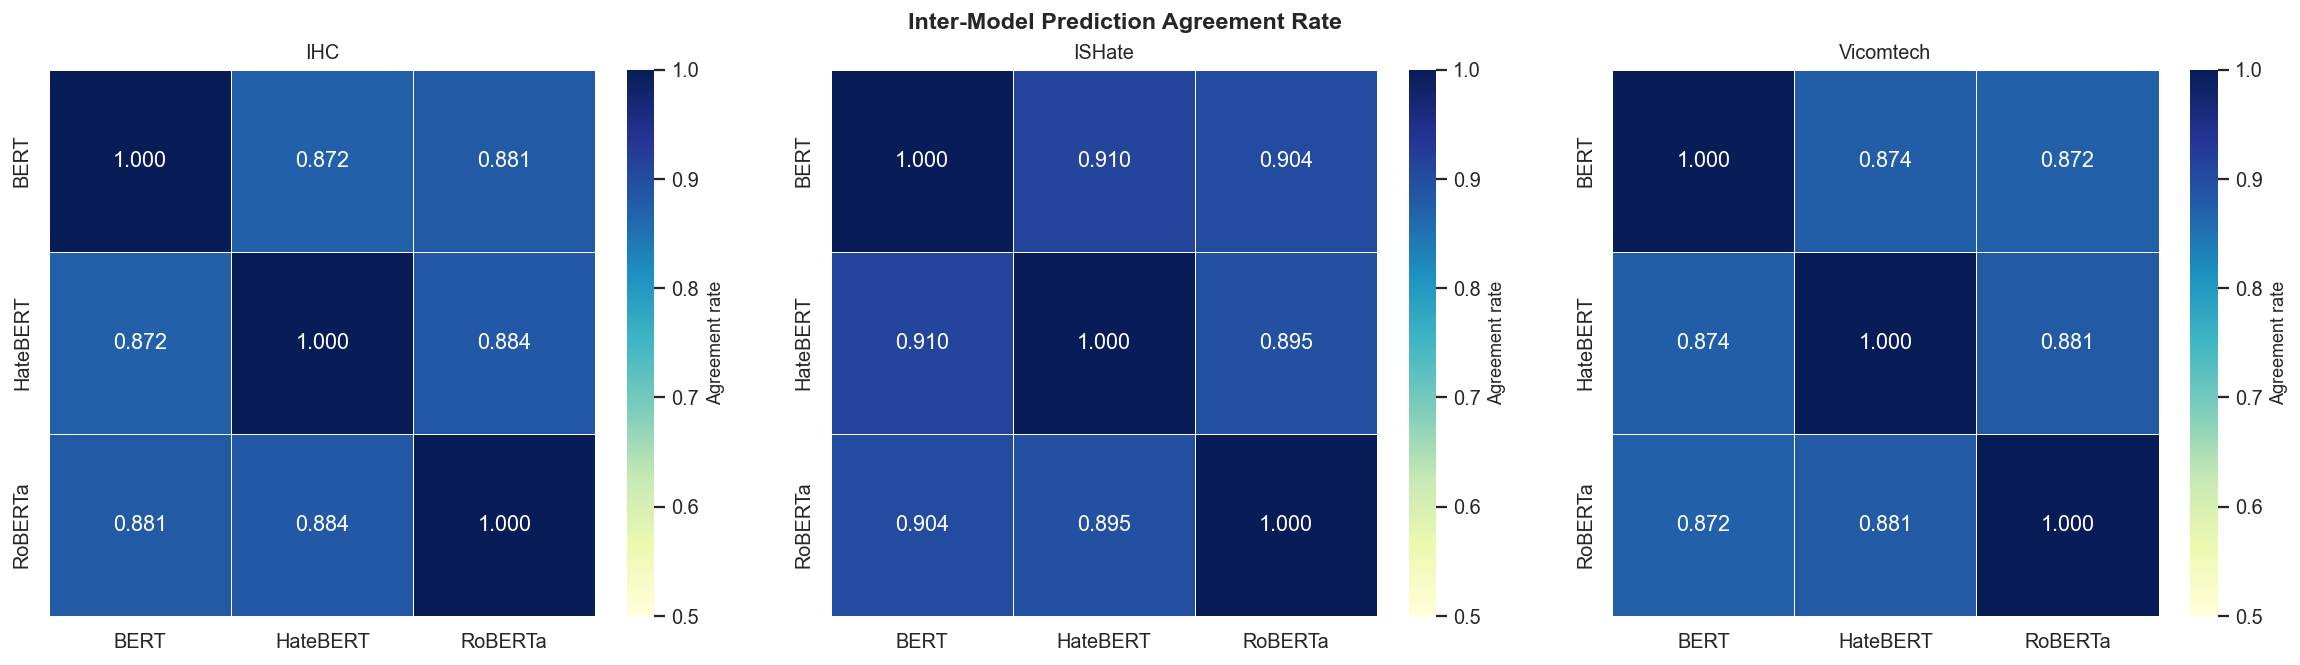

In [124]:
fig, axes = plt.subplots(1, len(DATASETS_CFG), figsize=(6*len(DATASETS_CFG), 5), constrained_layout=True)
fig.suptitle('Inter-Model Prediction Agreement Rate', fontsize=13, fontweight='bold')

for ax, dataset_name in zip(axes, list(DATASETS_CFG.keys())):
    model_list  = list(MODELS.keys())
    short_names = [MODEL_SHORT[m] for m in model_list]
    n_models    = len(model_list)
    agree_mat   = np.zeros((n_models, n_models))

    for i, mn1 in enumerate(model_list):
        for j, mn2 in enumerate(model_list):
            p1 = all_results[(mn1, dataset_name)]['predicted']
            p2 = all_results[(mn2, dataset_name)]['predicted']
            agree_mat[i, j] = (p1 == p2).mean()

    df_agree = pd.DataFrame(agree_mat, index=short_names, columns=short_names)
    sns.heatmap(df_agree, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0.5, vmax=1.0, ax=ax, square=True,
                linewidths=0.5, cbar_kws={'label': 'Agreement rate'})
    ax.set_title(dataset_name)

plt.savefig('fig13_agreement_matrix.png', bbox_inches='tight')
plt.show()

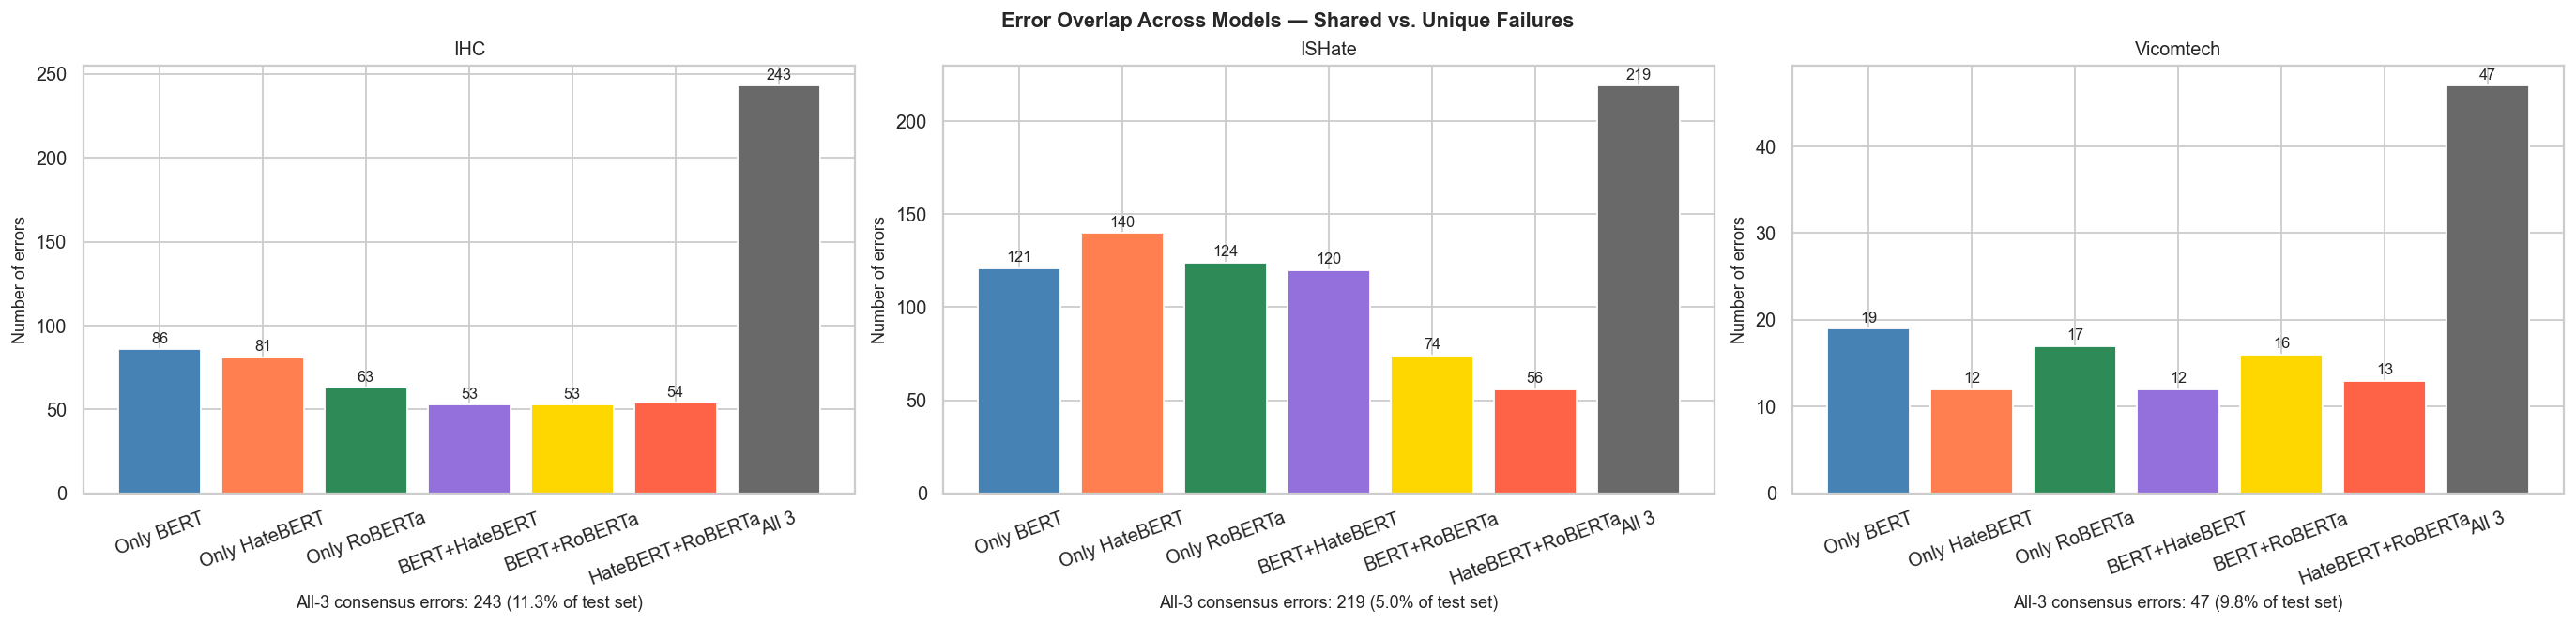

In [125]:
fig, axes = plt.subplots(1, len(DATASETS_CFG), figsize=(7*len(DATASETS_CFG), 5), constrained_layout=True)
fig.suptitle('Error Overlap Across Models — Shared vs. Unique Failures', fontsize=12, fontweight='bold')

for ax, dataset_name in zip(axes, list(DATASETS_CFG.keys())):
    model_list = list(MODELS.keys())
    errors     = {mn: ~all_results[(mn, dataset_name)]['correct'] for mn in model_list}
    n          = len(all_results[(model_list[0], dataset_name)]['labels'])

    overlap = {}
    # Unique to each model
    for mn in model_list:
        others = [m for m in model_list if m != mn]
        mask = errors[mn].copy()
        for o in others:
            mask = mask & ~errors[o]
        overlap[f'Only {MODEL_SHORT[mn]}'] = int(mask.sum())

    # Pairwise only (not the third)
    for mn1, mn2 in combinations(model_list, 2):
        mn3  = [m for m in model_list if m not in [mn1, mn2]][0]
        mask = errors[mn1] & errors[mn2] & ~errors[mn3]
        overlap[f'{MODEL_SHORT[mn1]}+{MODEL_SHORT[mn2]}'] = int(mask.sum())

    # All three
    mask_all = errors[model_list[0]] & errors[model_list[1]] & errors[model_list[2]]
    overlap['All 3'] = int(mask_all.sum())

    keys  = list(overlap.keys())
    vals  = list(overlap.values())
    bar_colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple', 'gold', 'tomato', 'dimgray']
    bars = ax.bar(keys, vals, color=bar_colors[:len(keys)])
    ax.bar_label(bars, fmt='%d', fontsize=9, padding=2)
    ax.set_title(f'{dataset_name}')
    ax.set_ylabel('Number of errors')
    ax.tick_params(axis='x', rotation=20)
    all3_pct = mask_all.sum() / n * 100
    ax.set_xlabel(f'All-3 consensus errors: {mask_all.sum()} ({all3_pct:.1f}% of test set)')

plt.savefig('fig14_error_overlap.png', bbox_inches='tight')
plt.show()

## 12. Summary

Key findings across all 6 model-dataset combinations.

In [126]:
print('=' * 70)
print('KEY FINDINGS')
print('=' * 70)

for dataset_name in list(DATASETS_CFG.keys()):
    print(f'\n{dataset_name}:')
    for model_name in MODELS:
        r        = all_results[(model_name, dataset_name)]
        macro_f1 = f1_score(r['labels'], r['predicted'], average='macro', zero_division=0)
        ece      = compute_ece(r['labels'], r['hs_prob'])
        gap      = r['confidence'][r['correct']].mean() - r['confidence'][~r['correct']].mean()
        pct_09   = (r['confidence'] < 0.90).mean() * 100
        n_fn_hc  = ((~r['correct']) & (r['labels'] == 1) & (r['predicted'] == 0) & (r['confidence'] > 0.85)).sum()
        print(f'  {MODEL_SHORT[model_name]:9s}: '
              f'F1={macro_f1:.3f} | ECE={ece:.3f} | ConfGap={gap:.3f} | '
              f'@t=0.90: {pct_09:.1f}% to RAG | High-conf FN (dangerous)={n_fn_hc}')

print()
print('Consensus failures (all 3 models wrong):')
for dataset_name in list(DATASETS_CFG.keys()):
    model_list = list(MODELS.keys())
    all_wrong = ~all_results[(model_list[0], dataset_name)]['correct']
    for mn in model_list[1:]:
        all_wrong = all_wrong & ~all_results[(mn, dataset_name)]['correct']
    n = len(all_results[(model_list[0], dataset_name)]['labels'])
    print(f'  {dataset_name}: {all_wrong.sum()} examples ({all_wrong.sum()/n*100:.1f}%)')

KEY FINDINGS

IHC:
  BERT     : F1=0.782 | ECE=0.121 | ConfGap=0.099 | @t=0.90: 25.4% to RAG | High-conf FN (dangerous)=154
  HateBERT : F1=0.783 | ECE=0.111 | ConfGap=0.090 | @t=0.90: 28.1% to RAG | High-conf FN (dangerous)=158
  RoBERTa  : F1=0.793 | ECE=0.090 | ConfGap=0.108 | @t=0.90: 32.8% to RAG | High-conf FN (dangerous)=136

ISHate:
  BERT     : F1=0.871 | ECE=0.105 | ConfGap=0.053 | @t=0.90: 4.7% to RAG | High-conf FN (dangerous)=237
  HateBERT : F1=0.871 | ECE=0.107 | ConfGap=0.050 | @t=0.90: 4.7% to RAG | High-conf FN (dangerous)=227
  RoBERTa  : F1=0.886 | ECE=0.094 | ConfGap=0.043 | @t=0.90: 3.3% to RAG | High-conf FN (dangerous)=205

Vicomtech:
  BERT     : F1=0.803 | ECE=0.115 | ConfGap=0.086 | @t=0.90: 24.5% to RAG | High-conf FN (dangerous)=28
  HateBERT : F1=0.824 | ECE=0.092 | ConfGap=0.136 | @t=0.90: 25.5% to RAG | High-conf FN (dangerous)=15
  RoBERTa  : F1=0.805 | ECE=0.134 | ConfGap=0.083 | @t=0.90: 15.3% to RAG | High-conf FN (dangerous)=31

Consensus failures (